# University Ranking and Graduate Salary Analysis

## Abstract

This project analyzes the relationship between university characteristics and graduate salaries. We combine information about universities, rankings, degree levels, fields of study, and alumni salary outcomes in order to understand which factors are associated with higher graduate earnings.

The project is developed by two team members. One part of the work focuses on data preparation, exploratory data analysis, hypothesis testing, and notebook-based reporting. The other part focuses on building and improving the Streamlit web interface for presenting the results interactively.

## Research questions

In this project, we focus on the following questions:

1. Is graduate salary associated with degree level?
2. Is university ranking associated with graduate salary?
3. Does field of study explain salary differences between graduates?
4. Does the relationship between university rank and salary differ across degree levels or fields of study?

## Project structure

The notebook follows the required report structure:

1. Dataset description
2. Data cleanup
3. Data transformation
4. Descriptive statistics
5. General data overview
6. Detailed comparisons
7. Hypothesis testing
8. Discussion and conclusions


In [680]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import pickle

In [681]:
university_rate = pd.read_csv("university_datasets.csv", encoding='latin-1')
alumni_first = pd.read_csv("job_placement.csv", encoding='utf-8')
alumni_second = pd.read_csv("global_graduate_employability_index.csv", encoding='latin-1')

alumni_second[alumni_second['University_Name'] == 'Harvard']

,Country,Region,University_Name,Degree_Level,Field_of_Study,Graduation_Year,Employment_Rate_6_Months (%),Employment_Rate_12_Months (%),Average_Starting_Salary_USD,Top_Industry,Job_Role,Skill_1,Skill_2,Skill_3,Skill_Demand_Score (1â100),Remote_Work_Availability (%),Employer_Reputation_Score (1â100),Year
0,USA,North America,Harvard,Bachelor,Engineering,2017,79.3,85.6,66700,Manufacturing/Construction,Robotics Engineer,AutoCAD,Lean Six Sigma,MATLAB,69,8.8,66,2017
52,USA,North America,Harvard,Bachelor,Natural Sciences,2018,84.1,91.7,61200,Research/Academia,Chemist,Statistical Analysis,Laboratory Skills,Scientific Writing,56,13.4,65,2018
88,USA,North America,Harvard,PhD,Healthcare & Medicine,2025,88.5,94.8,149100,Healthcare,Biomedical Researcher,Patient Care,Diagnostics,Clinical Research,53,89.3,51,2025
97,USA,North America,Harvard,PhD,Engineering,2019,94.4,99.7,112100,Manufacturing/Construction,Mechanical Engineer,SolidWorks,Lean Six Sigma,AutoCAD,60,7.7,57,2019
163,USA,North America,Harvard,Master,Social Sciences,2025,85.1,91.6,70600,Government/NGO,Sociologist,Data Analysis,Public Policy,Communication,74,80.3,69,2025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3358,USA,North America,Harvard,PhD,Computer Science,2016,82.6,86.7,108900,Technology,Cybersecurity Analyst,React,Cloud Computing,Java,54,16.8,58,2016
3400,USA,North America,Harvard,PhD,Natural Sciences,2020,84.0,93.0,94200,Research/Academia,Chemist,Experimental Design,Statistical Analysis,Laboratory Skills,54,29.6,52,2020
3413,USA,North America,Harvard,Bachelor,Social Sciences,2020,74.3,77.3,44100,Government/NGO,Economist,Public Policy,Qualitative Research,Data Analysis,51,35.8,84,2020
3424,USA,North America,Harvard,Bachelor,Data Science & AI,2016,91.3,96.8,78100,Technology/Consulting,Machine Learning Engineer,Deep Learning,Machine Learning,Big Data,72,9.3,56,2016


In [682]:
university_full_names = {
    'Harvard': 'Harvard University',
    'MIT': 'Massachusetts Institute of Technology',
    'Technion': 'Technion – Israel Institute of Technology',
    'IIT Bombay': 'Indian Institute of Technology Bombay',
    'University of Cape Town': 'University of Cape Town',
    'LSE': 'London School of Economics and Political Science',
    'Karolinska Institute': 'Karolinska Institute',
    'University of Amsterdam': 'University of Amsterdam',
    'Imperial College London': 'Imperial College London',
    'UNAM': 'National Autonomous University of Mexico',
    'Hebrew University of Jerusalem': 'Hebrew University of Jerusalem',
    'KTH Royal Institute of Technology': 'Royal Institute of Technology',
    'Seoul National University': 'Seoul National University',
    'NUS': 'National University of Singapore',
    'University of São Paulo': 'University of São Paulo',
    'University of Toronto': 'University of Toronto',
    'ANU': 'Australian National University',
    'University of Buenos Aires': 'University of Buenos Aires',
    'King Abdulaziz University': 'King Abdulaziz University',
    'Fudan University': 'Fudan University',
    'Stanford': 'Stanford University',
    'McGill University': 'McGill University',
    'UBC': 'University of British Columbia',
    'PSL University': 'Paris Sciences et Lettres University',
    'Khalifa University': 'Khalifa University',
    'Ecole Polytechnique': 'École Polytechnique',
    'UC Berkeley': 'University of California, Berkeley',
    'University of Melbourne': 'University of Melbourne',
    'University of Sydney': 'University of Sydney',
    'EPFL': 'École Polytechnique Fédérale de Lausanne',
    'ETH Zurich': 'Swiss Federal Institute of Technology Zurich',
    'TU Munich': 'Technical University of Munich',
    'TU Delft': 'Delft University of Technology',
    'Heidelberg University': 'Heidelberg University',
    'University of Tokyo': 'University of Tokyo',
    'Kyoto University': 'Kyoto University',
    'KAIST': 'Korea Advanced Institute of Science and Technology',
    'IIT Delhi': 'Indian Institute of Technology Delhi',
    'IISc Bangalore': 'Indian Institute of Science Bangalore',
    'University of Washington': 'University of Washington - Seattle',
    'Georgia Tech': 'Georgia Institute of Technology',
    'Peking University': 'Peking University',
    'Tsinghua University': 'Tsinghua University',
    'NTU': 'Nanyang Technological University',
    'University of Oxford': 'University of Oxford',
    'University of Cambridge': 'University of Cambridge',
    'University of Chicago': 'University of Chicago',
    'Yale University': 'Yale University',
    'Columbia University': 'Columbia University',
    'Princeton University': 'Princeton University',
    'Caltech': 'California Institute of Technology',
    'Johns Hopkins University': 'Johns Hopkins University',
    'University of Pennsylvania': 'University of Pennsylvania',
    'Cornell University': 'Cornell University',
    'UCLA': 'University of California, Los Angeles',
    'University of Michigan': 'University of Michigan, Ann Arbor',
    'UCSD': 'University of California, San Diego',
    'Northwestern University': 'Northwestern University',
    'Duke University': 'Duke University',
    'NYU': 'New York University',
    'University of Wisconsin': 'University of Wisconsin–Madison',
    'Sorbonne University': 'Sorbonne University',
    'University of Texas at Austin': 'University of Texas at Austin',
    'UIUC': 'University of Illinois at Urbana–Champaign',
    'UNC Chapel Hill': 'University of North Carolina at Chapel Hill',
    'University of Edinburgh': 'University of Edinburgh',
    'University of Minnesota': 'University of Minnesota Twin Cities',
    'WUSTL': 'Washington University in St. Louis',
    'University of Copenhagen': 'University of Copenhagen',
    'Ohio State University': 'Ohio State University',
    'Rutgers University': 'Rutgers University-New Brunswick',
    'UCDavis': 'University of California, Davis',
    'Penn State': 'Pennsylvania State University',
    'University of Manchester': 'University of Manchester',
    'Weizmann Institute': 'Weizmann Institute of Science',
    'LMU Munich': 'Ludwig Maximilian University of Munich',
    'University of Colorado Boulder': 'University of Colorado Boulder',
    'USC': 'University of Southern California',
    'University of Arizona': 'University of Arizona',
    'Osaka University': 'Osaka University',
    'University of Geneva': 'University of Geneva',
    'Boston University': 'Boston University',
    'Brown University': 'Brown University',
    'UCI': 'University of California, Irvine',
    'University of Florida': 'University of Florida',
    'Purdue University': 'Purdue University, West Lafayette',
    'Vanderbilt University': 'Vanderbilt University',
    'University of Bristol': 'University of Bristol',
    'Sapienza University of Rome': 'Sapienza University of Rome',
    'King\'s College London': 'King\'s College London',
    'University of Zurich': 'University of Zurich',
    'UCSB': 'University of California, Santa Barbara',
    'Utrecht University': 'Utrecht University',
    'University of Pittsburgh': 'University of Pittsburgh',
    'University of Queensland': 'University of Queensland',
    'University of Oslo': 'University of Oslo',
    'Rockefeller University': 'Rockefeller University',
    'Texas A&M': 'Texas A&M University, College Station',
    'University of Virginia': 'University of Virginia',
    'Emory University': 'Emory University',
    'Free University of Berlin': 'Free University of Berlin',
    'University of Utah': 'University of Utah',
    'Tel Aviv University': 'Tel Aviv University',
    'Uppsala University': 'Uppsala University',
    'University of Barcelona': 'University of Barcelona',
    'Aarhus University': 'Aarhus University',
    'Leiden University': 'Leiden University',
    'Carnegie Mellon University': 'Carnegie Mellon University',
    'University of Helsinki': 'University of Helsinki',
    'Lund University': 'Lund University',
    'University of Alberta': 'University of Alberta',
    'University of Basel': 'University of Basel',
    'University of Groningen': 'University of Groningen',
    'Humboldt University of Berlin': 'Humboldt University of Berlin',
    'Ghent University': 'Ghent University',
    'University of Rochester': 'University of Rochester',
    'Erasmus University Rotterdam': 'Erasmus University Rotterdam',
    'KU Leuven': 'KU Leuven',
    'University of Bern': 'University of Bern',
    'National Taiwan University': 'National Taiwan University',
    'University of Montreal': 'University of Montreal',
    'Nagoya University': 'Nagoya University',
    'Arizona State University': 'Arizona State University',
    'University of Bonn': 'University of Bonn',
    'University of Nottingham': 'University of Nottingham',
    'UNSW': 'University of New South Wales',
    'Tohoku University': 'Tohoku University',
    'McMaster University': 'McMaster University',
    'Dartmouth College': 'Dartmouth College',  
    'Monash University': 'Monash University',
    'University of Hamburg': 'University of Hamburg',
    'Moscow State University': 'Moscow State University',
    'VU Amsterdam': 'VU University Amsterdam',
    'Stony Brook University': 'Stony Brook University',
    'Rice University': 'Rice University',
    'Radboud University': 'Radboud University Nijmegen',
    'Cardiff University': 'Cardiff University',
    'University of Tübingen': 'University of Tübingen',
    'University of Iowa': 'University of Iowa',
    'University of Strasbourg': 'University of Strasbourg',
    'Shanghai Jiao Tong University': 'Shanghai Jiao Tong University',
    'University of Southampton': 'University of Southampton',
    'Tokyo Institute of Technology': 'Tokyo Institute of Technology',
    'Case Western Reserve University': 'Case Western Reserve University',
    'Indiana University Bloomington': 'Indiana University Bloomington',
    'Michigan State University': 'Michigan State University',
    'University of Western Australia': 'University of Western Australia',
    'University of Lausanne': 'University of Lausanne',
    'University of Milan': 'University of Milan',
    'Goethe University Frankfurt': 'Goethe University Frankfurt',
    'University of Padua': 'University of Padua',
    'Autonomous University of Barcelona': 'Autonomous University of Barcelona',
    'Tufts University': 'Tufts University',
    'University of Göttingen': 'University of Göttingen',
    'Zhejiang University': 'Zhejiang University',
    'University of Glasgow': 'University of Glasgow',
    'Stockholm University': 'Stockholm University',
    'University of Notre Dame': 'University of Notre Dame',
    'University of Sheffield': 'University of Sheffield',
    'University of Warwick': 'University of Warwick',
    'University of Leeds': 'University of Leeds',
    'University of Freiburg': 'University of Freiburg',
    'University of Gothenburg': 'University of Gothenburg',
    'North Carolina State University': 'North Carolina State University',
    'Wageningen University': 'Wageningen University and Research',
    'University of Birmingham': 'University of Birmingham',
    'University of Hong Kong': 'University of Hong Kong',
    'University of Vienna': 'University of Vienna',
    'Hokkaido University': 'Hokkaido University',
    'Keio University': 'Keio University',
    'University of SÃ£o Paulo' : 'University of São Paulo'
}

def add_institution_status(name):
    if any(x in name for x in ['University', 'College', 'School', 'Institute', 'Institute of Technology']):
        return name
    
    special_cases = {
        'Dartmouth College': 'Dartmouth College', 
        'London School of Economics': 'London School of Economics and Political Science',
        'Karolinska Institute': 'Karolinska Institute',
        'Weizmann Institute of Science': 'Weizmann Institute of Science',
        'Technion': 'Technion – Israel Institute of Technology',
        'École Polytechnique': 'École Polytechnique',
    }
    
    if name in special_cases:
        return special_cases[name]
    
    if 'Institute' in name or 'College' in name:
        return name
    
    return f"{name} University"

alumni_second['University_Name'] = alumni_second['University_Name'].replace(university_full_names)
alumni_second['University_Name'] = alumni_second['University_Name'].apply(add_institution_status)

## 1. Dataset description

The project uses a composite dataset built from several sources. The main dataframe for alumni analysis is `alumni_data`, which contains information about universities, graduate degree level, field of study, salary, and university ranking.

The most important columns for our analysis are:

* `University`: name of the university
* `Degree`: graduate degree level, such as Bachelor, Master, or PhD
* `Field`: field of study
* `Salary (USD per year)`: graduate salary in USD per year
* `University Rate`: university world ranking position

The dataset contains both categorical and numerical variables. Categorical variables are useful for group comparisons, while numerical variables allow us to compute descriptive statistics, correlations, and regression models.


In [683]:
alumni_second.head(20)

,Country,Region,University_Name,Degree_Level,Field_of_Study,Graduation_Year,Employment_Rate_6_Months (%),Employment_Rate_12_Months (%),Average_Starting_Salary_USD,Top_Industry,Job_Role,Skill_1,Skill_2,Skill_3,Skill_Demand_Score (1â100),Remote_Work_Availability (%),Employer_Reputation_Score (1â100),Year
0,USA,North America,Harvard University,Bachelor,Engineering,2017,79.3,85.6,66700,Manufacturing/Construction,Robotics Engineer,AutoCAD,Lean Six Sigma,MATLAB,69,8.8,66,2017
1,USA,North America,Massachusetts Institute of Technology,Bachelor,Engineering,2023,83.8,87.9,84500,Manufacturing/Construction,Civil Engineer,Lean Six Sigma,AutoCAD,MATLAB,71,65.4,63,2023
2,Israel,Middle East & Africa,Technion – Israel Institute of Technology,Master,Healthcare & Medicine,2019,81.7,83.2,88300,Healthcare,Public Health Specialist,Clinical Research,Diagnostics,Patient Care,52,5.0,74,2019
3,India,Asia-Pacific,Indian Institute of Technology Bombay,Master,Computer Science,2016,84.2,92.1,21000,Technology,AI Researcher,DevOps,Python,Cloud Computing,69,10.3,48,2016
4,South Africa,Middle East & Africa,University of Cape Town,PhD,Business & Finance,2023,83.6,86.3,48600,Finance/Consulting,Management Consultant,Financial Modeling,Data Analysis,Market Research,69,64.0,65,2023
5,South Africa,Middle East & Africa,University of Cape Town,PhD,Computer Science,2015,99.0,100.0,39200,Technology,Software Engineer,React,Java,Cloud Computing,59,14.1,51,2015
6,UK,Europe,London School of Economics and Political Science,Master,Business & Finance,2025,71.5,73.8,86000,Finance/Consulting,Management Consultant,Excel,Strategic Planning,Data Analysis,71,90.0,72,2025
7,Sweden,Europe,Karolinska Institute,PhD,Social Sciences,2025,81.5,83.5,79800,Government/NGO,Economist,Public Policy,Communication,Data Analysis,62,85.4,85,2025
8,Netherlands,Europe,University of Amsterdam,Master,Social Sciences,2023,72.4,78.1,60900,Government/NGO,Policy Analyst,Qualitative Research,Communication,Data Analysis,62,63.2,79,2023
9,UK,Europe,Imperial College London,Master,Data Science & AI,2016,95.9,99.2,78800,Technology/Consulting,Data Analyst,Deep Learning,Big Data,R,68,11.7,84,2016


In [684]:
alumni_data = pd.DataFrame()
alumni_data["University"] = pd.concat([alumni_first.college_name, alumni_second.University_Name], axis=0, ignore_index=True)
alumni_data["Degree"] = pd.concat([alumni_first.degree, alumni_second.Degree_Level], axis=0, ignore_index=True)
alumni_data["Field"] = pd.concat([alumni_first.stream, alumni_second.Field_of_Study], axis=0, ignore_index=True)
alumni_data["Salary (USD per year)"] = pd.concat([alumni_first.salary, alumni_second.Average_Starting_Salary_USD], axis=0, ignore_index=True)

In [685]:
alumni_data.Degree = alumni_data.Degree.replace("Bachelor's", "Bachelor")
alumni_data.Field = alumni_data.Field.replace(["Electrical Engineering", "Mechanical Engineering"], "Engineering")
alumni_data.Field = alumni_data.Field.replace(["Data Science & AI", "Information Technology", "Electronics and Communication", "Computer Science"], "IT")
alumni_data = alumni_data[alumni_data["Salary (USD per year)"] > 10000]
alumni_data = alumni_data[alumni_data.University.isin(set(alumni_data.University) & set(university_rate.Institution))]
rank_dict = university_rate.set_index('Institution')['World Rank'].to_dict()
alumni_data['University Rate'] = alumni_data["University"].map(rank_dict)
alumni_data.head()

,University,Degree,Field,Salary (USD per year),University Rate
0,Harvard University,Bachelor,IT,60000,1
1,Massachusetts Institute of Technology,Bachelor,Engineering,65000,3
2,Stanford University,Bachelor,Engineering,58000,2
4,Princeton University,Bachelor,IT,62000,7
5,Columbia University,Bachelor,IT,63000,8


## 2. Data cleanup

Before performing statistical analysis, we clean and validate the main dataframe `alumni_data`.

The cleanup step has several goals:

1. Check whether important columns have missing values.
2. Convert numerical columns to proper numeric format.
3. Remove invalid salary and ranking values.
4. Standardize the dataset used for university-level comparisons.
5. Preserve the full cleaned dataset before applying additional filtering.

This is important because later analysis depends on salary and university ranking values being valid numerical variables.

In [686]:
# Main columns used in the analysis

salary_col = "Salary (USD per year)"
rank_col = "University Rate"

required_columns = [
    "University",
    "Degree",
    "Field",
    salary_col,
    rank_col
]

cleanup_report_before = pd.DataFrame({
    "Column": required_columns,
    "Missing values": [alumni_data[column].isna().sum() for column in required_columns],
    "Unique values": [alumni_data[column].nunique() for column in required_columns],
    "Data type": [alumni_data[column].dtype for column in required_columns]
})

cleanup_report_before

,Column,Missing values,Unique values,Data type
0,University,0,52,str
1,Degree,0,3,str
2,Field,0,6,str
3,Salary (USD per year),0,1034,int64
4,University Rate,0,52,int64


In [687]:
# Create a cleaned copy of alumni_data.

alumni_data = alumni_data.copy()

alumni_data[salary_col] = pd.to_numeric(
    alumni_data[salary_col],
    errors="coerce"
)

alumni_data[rank_col] = pd.to_numeric(
    alumni_data[rank_col],
    errors="coerce"
)

alumni_data = alumni_data.dropna(subset=required_columns)

alumni_data = alumni_data[
    (alumni_data[salary_col] > 0) &
    (alumni_data[rank_col] > 0)
].copy()

alumni_data = alumni_data.reset_index(drop=True)

print("Shape after basic cleanup:", alumni_data.shape)

Shape after basic cleanup: (2943, 5)


In [688]:
degree_distribution = (
    alumni_data["Degree"]
    .value_counts()
    .rename_axis("Degree")
    .reset_index(name="Number of graduates")
)

field_distribution = (
    alumni_data["Field"]
    .value_counts()
    .rename_axis("Field")
    .reset_index(name="Number of graduates")
)

display(degree_distribution)
display(field_distribution)

,Degree,Number of graduates
0,Bachelor,1085
1,PhD,943
2,Master,915


,Field,Number of graduates
0,IT,919
1,Engineering,472
2,Social Sciences,397
3,Natural Sciences,395
4,Healthcare & Medicine,383
5,Business & Finance,377


The tables above show the distribution of observations by degree level and field of study. This allows us to check whether the dataset is balanced or whether some categories dominate the analysis.

If one degree level or field has many more observations than others, later comparisons should be interpreted carefully.

In [689]:
# Preserve the full cleaned alumni dataset before university-level filtering.
# Later analysis can use alumni_data_full if all observations are needed.

alumni_data_full = alumni_data.copy()

min_university_observations = 20

university_counts = alumni_data["University"].value_counts()

valid_universities = university_counts[
    university_counts >= min_university_observations
].index

alumni_data = alumni_data[
    alumni_data["University"].isin(valid_universities)
].copy()

alumni_data = alumni_data.reset_index(drop=True)

filtering_summary = pd.DataFrame({
    "Metric": [
        "Rows before university filtering",
        "Rows after university filtering",
        "Universities before filtering",
        "Universities after filtering",
        "Minimum observations per selected university"
    ],
    "Value": [
        len(alumni_data_full),
        len(alumni_data),
        alumni_data_full["University"].nunique(),
        alumni_data["University"].nunique(),
        min_university_observations
    ]
})

filtering_summary

,Metric,Value
0,Rows before university filtering,2943
1,Rows after university filtering,2930
2,Universities before filtering,52
3,Universities after filtering,39
4,Minimum observations per selected university,20


In [690]:
alumni_data.head()

,University,Degree,Field,Salary (USD per year),University Rate
0,Harvard University,Bachelor,IT,60000,1
1,Massachusetts Institute of Technology,Bachelor,Engineering,65000,3
2,Stanford University,Bachelor,Engineering,58000,2
3,University of Rochester,Bachelor,IT,61000,105
4,University of Connecticut,Bachelor,Engineering,61000,193


After filtering, `alumni_data` contains universities with at least 20 alumni records. This filtered dataframe is used for university-level salary comparisons because average salaries based on very few observations may be unstable.

The full cleaned dataset is preserved as `alumni_data_full`.

In [691]:
# ----------------------- ADDED by Maksim, today -------------------------------
#       Basic overview of the main dataframe used for analysis

print("Shape of alumni_data:", alumni_data.shape)

display(alumni_data.head())

dataset_overview = pd.DataFrame({
    "Column": alumni_data.columns,
    "Data type": alumni_data.dtypes.astype(str).values,
    "Missing values": alumni_data.isna().sum().values,
    "Unique values": alumni_data.nunique().values
})

dataset_overview

Shape of alumni_data: (2930, 5)


,University,Degree,Field,Salary (USD per year),University Rate
0,Harvard University,Bachelor,IT,60000,1
1,Massachusetts Institute of Technology,Bachelor,Engineering,65000,3
2,Stanford University,Bachelor,Engineering,58000,2
3,University of Rochester,Bachelor,IT,61000,105
4,University of Connecticut,Bachelor,Engineering,61000,193


,Column,Data type,Missing values,Unique values
0,University,str,0,39
1,Degree,str,0,3
2,Field,str,0,6
3,Salary (USD per year),int64,0,1034
4,University Rate,int64,0,39


The table above gives a first overview of the main dataframe. It shows the data type of each column, the number of missing values, and the number of unique values. This helps us understand whether additional cleanup or type conversion is required before performing statistical analysis.


## 3. Data transformation and descriptive statistics

After cleaning the main alumni dataframe, we create additional numerical variables that will be useful for further analysis.

The original dataframe contains two main numerical columns:

- `Salary (USD per year)`
- `University Rate`

However, the project requirements ask us to analyze several numerical variables. Therefore, we create additional transformed columns based on existing data:

- `Log University Rank`: logarithmic transformation of university rank
- `Degree Code`: numerical representation of degree level
- `Salary Relative to Field Median`: salary compared to the median salary in the same field
- `Salary Percentile`: percentile position of a graduate's salary in the dataset

These transformations help us analyze salary differences more carefully and prepare the dataset for hypothesis testing.

In [692]:
# Prepare a separate dataframe for transformed salary analysis.
# We keep alumni_data unchanged and use analysis_data for additional variables.

analysis_data = alumni_data.copy()

salary_col = "Salary (USD per year)"
rank_col = "University Rate"

analysis_data[salary_col] = pd.to_numeric(
    analysis_data[salary_col],
    errors="coerce"
)

analysis_data[rank_col] = pd.to_numeric(
    analysis_data[rank_col],
    errors="coerce"
)

analysis_data = analysis_data.dropna(
    subset=["University", "Degree", "Field", salary_col, rank_col]
)

analysis_data = analysis_data[
    (analysis_data[salary_col] > 0) &
    (analysis_data[rank_col] > 0)
].copy()

degree_order = ["Bachelor", "Master", "PhD"]

degree_code_map = {
    "Bachelor": 1,
    "Master": 2,
    "PhD": 3
}

analysis_data["Degree"] = pd.Categorical(
    analysis_data["Degree"],
    categories=degree_order,
    ordered=True
)

analysis_data["Degree Code"] = analysis_data["Degree"].map(degree_code_map).astype(int)

analysis_data["Log University Rank"] = np.log10(
    analysis_data[rank_col]
)

field_median_salary = analysis_data.groupby("Field")[salary_col].transform("median")

analysis_data["Salary Relative to Field Median"] = (
    analysis_data[salary_col] / field_median_salary
)

analysis_data["Salary Percentile"] = (
    analysis_data[salary_col].rank(pct=True) * 100
)

analysis_data.head()

,University,Degree,Field,Salary (USD per year),University Rate,Degree Code,Log University Rank,Salary Relative to Field Median,Salary Percentile
0,Harvard University,Bachelor,IT,60000,1,1,0.000000,0.923077,47.508532
1,Massachusetts Institute of Technology,Bachelor,Engineering,65000,3,1,0.477121,1.048387,57.098976
2,Stanford University,Bachelor,Engineering,58000,2,1,0.301030,0.935484,45.255973
3,University of Rochester,Bachelor,IT,61000,105,1,2.021189,0.938462,49.215017
4,University of Connecticut,Bachelor,Engineering,61000,193,1,2.285557,0.983871,49.215017


The transformed dataframe `analysis_data` keeps the original alumni information and adds several numerical variables.

`Log University Rank` is useful because university rankings are unevenly distributed. The difference between rank 1 and rank 10 is usually more meaningful than the difference between rank 501 and rank 510, so a logarithmic scale can give a more balanced representation.

`Degree Code` allows us to compare degree levels numerically.

`Salary Relative to Field Median` helps compare graduates inside their own fields. A value above `1.0` means that the salary is higher than the median salary in that field.

`Salary Percentile` shows the relative position of each salary in the full salary distribution.

In [693]:
numeric_columns = [
    salary_col,
    rank_col,
    "Log University Rank",
    "Degree Code",
    "Salary Relative to Field Median",
    "Salary Percentile"
]

descriptive_statistics = (
    analysis_data[numeric_columns]
    .describe()
    .T
    .round(3)
)

descriptive_statistics

,count,mean,std,min,25%,50%,75%,max
Salary (USD per year),2930.0,61638.328,29334.874,10100.000,36700.000,61200.000,81275.000,152200.000
University Rate,2930.0,143.694,134.718,1.000,38.000,98.000,258.000,671.000
Log University Rank,2930.0,1.868,0.637,0.000,1.580,1.991,2.412,2.827
Degree Code,2930.0,1.956,0.828,1.000,1.000,2.000,3.000,3.000
Salary Relative to Field Median,2930.0,1.010,0.462,0.158,0.597,1.000,1.341,2.342
Salary Percentile,2930.0,50.017,28.872,0.034,25.051,50.051,75.026,100.000


The descriptive statistics table summarizes the main numerical variables used in the project. It includes the number of observations, mean, standard deviation, minimum, quartiles, and maximum values.

This allows us to understand the scale and distribution of salary, university ranking, and the transformed variables before moving to more detailed visual analysis and hypothesis testing.

In [694]:
transformation_check = pd.DataFrame({
    "Column": analysis_data.columns,
    "Missing values": analysis_data.isna().sum().values,
    "Unique values": analysis_data.nunique().values,
    "Data type": analysis_data.dtypes.astype(str).values
})

transformation_check

,Column,Missing values,Unique values,Data type
0,University,0,39,str
1,Degree,0,3,category
2,Field,0,6,str
3,Salary (USD per year),0,1034,int64
4,University Rate,0,39,int64
5,Degree Code,0,3,int64
6,Log University Rank,0,39,float64
7,Salary Relative to Field Median,0,2188,float64
8,Salary Percentile,0,1034,float64


The table above checks the transformed dataframe after new columns were created. This confirms that the variables needed for later analysis do not contain unexpected missing values and have appropriate data types.

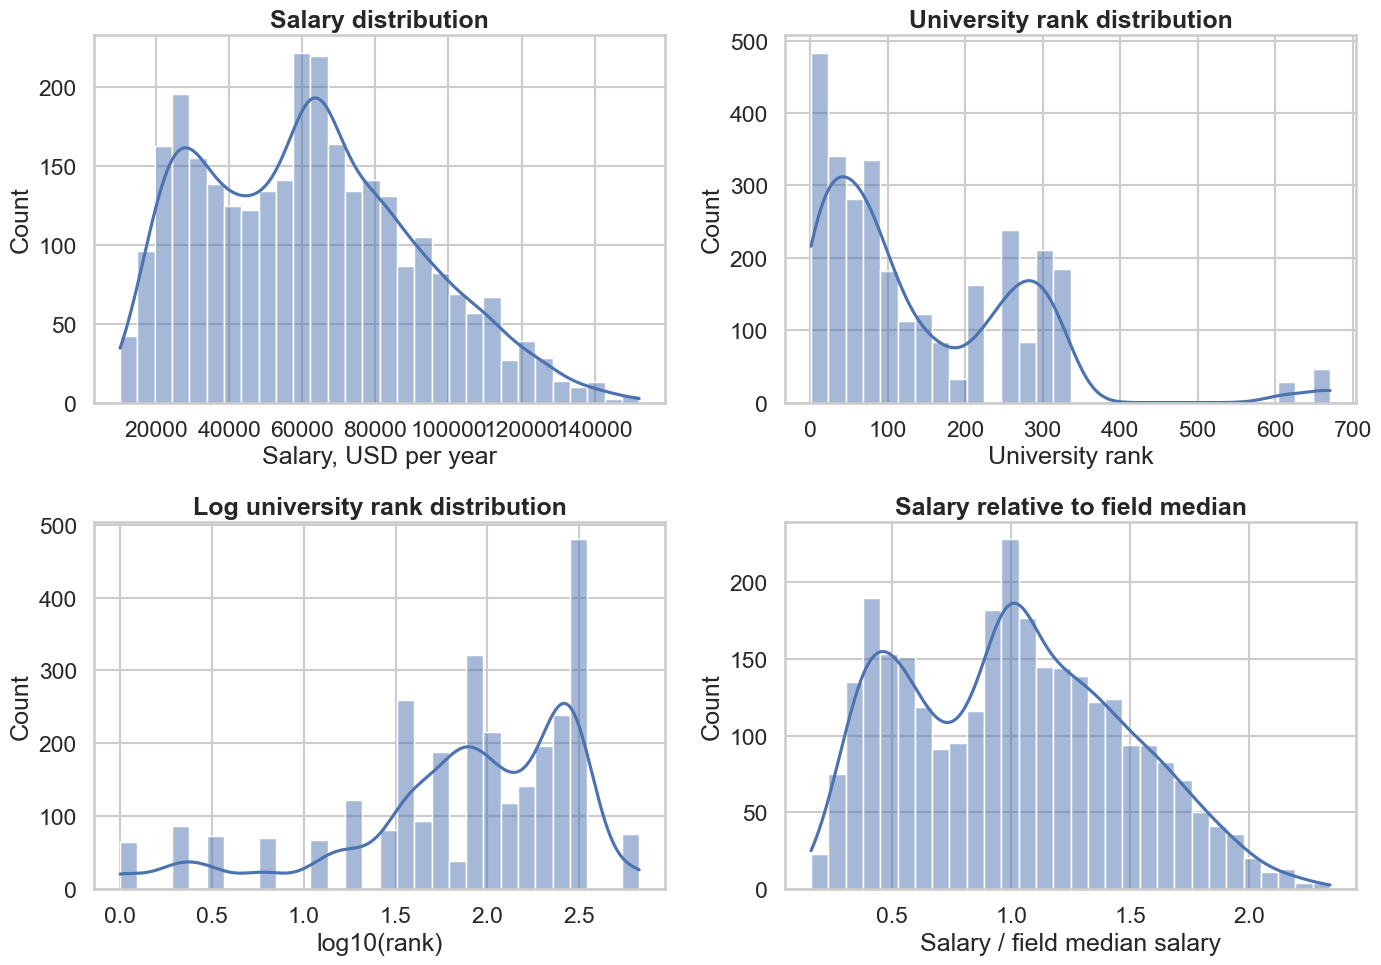

In [695]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(
    analysis_data[salary_col],
    bins=30,
    kde=True,
    ax=axes[0, 0]
)
axes[0, 0].set_title("Salary distribution")
axes[0, 0].set_xlabel("Salary, USD per year")

sns.histplot(
    analysis_data[rank_col],
    bins=30,
    kde=True,
    ax=axes[0, 1]
)
axes[0, 1].set_title("University rank distribution")
axes[0, 1].set_xlabel("University rank")

sns.histplot(
    analysis_data["Log University Rank"],
    bins=30,
    kde=True,
    ax=axes[1, 0]
)
axes[1, 0].set_title("Log university rank distribution")
axes[1, 0].set_xlabel("log10(rank)")

sns.histplot(
    analysis_data["Salary Relative to Field Median"],
    bins=30,
    kde=True,
    ax=axes[1, 1]
)
axes[1, 1].set_title("Salary relative to field median")
axes[1, 1].set_xlabel("Salary / field median salary")

plt.tight_layout()
plt.show()

The plots above show the distributions of the main numerical variables.

Salary distribution helps us understand how graduate earnings are spread across the dataset. University ranking is strongly uneven, which supports the decision to create the `Log University Rank` variable. The relative salary variable allows us to compare salaries across fields with different typical salary levels.

## 4. Detailed overview of salary factors

After checking the general numerical distributions, we now compare salaries across the main categorical factors in the dataset.

This section focuses on four detailed comparisons:

1. Salary by degree level
2. Salary by field of study
3. Salary by university rank group
4. Salary by both degree level and field of study

These comparisons help us understand which variables may be useful for later hypothesis testing.

In [696]:
# Create interpretable university rank groups for detailed comparison.

rank_bins = [0, 10, 50, 100, 300, 1000]
rank_labels = ["Top 10", "11-50", "51-100", "101-300", "301+"]

analysis_data["Rank Group"] = pd.cut(
    analysis_data[rank_col],
    bins=rank_bins,
    labels=rank_labels,
    include_lowest=True
)

analysis_data[["University", rank_col, "Rank Group"]].drop_duplicates().sort_values(rank_col).head(10)

,University,University Rate,Rank Group
0,Harvard University,1,Top 10
2,Stanford University,2,Top 10
1,Massachusetts Institute of Technology,3,Top 10
177,"University of California, Berkeley",6,Top 10
184,University of Tokyo,12,11-50
161,University of Toronto,17,11-50
303,Kyoto University,26,11-50
153,Imperial College London,30,11-50
171,McGill University,37,11-50
172,University of British Columbia,38,11-50


University ranks are transformed into broader rank groups. This makes comparison easier because individual rank numbers are very unevenly distributed. For example, the difference between rank 1 and rank 10 may be more important than the difference between rank 501 and rank 510.

The rank groups allow us to compare salary distributions for universities in different ranking categories.

In [697]:
salary_by_degree = (
    analysis_data
    .groupby("Degree", observed=True)[salary_col]
    .agg(
        number_of_graduates="count",
        mean_salary="mean",
        median_salary="median",
        salary_std="std",
        min_salary="min",
        max_salary="max"
    )
    .round(2)
)

salary_by_degree

,number_of_graduates,mean_salary,median_salary,salary_std,min_salary,max_salary
Degree,,,,,,
Bachelor,1072,49781.81,54400.0,19878.85,10100,95400
Master,915,59208.42,61600.0,26578.32,10600,125700
PhD,943,77474.55,82300.0,33529.66,13500,152200


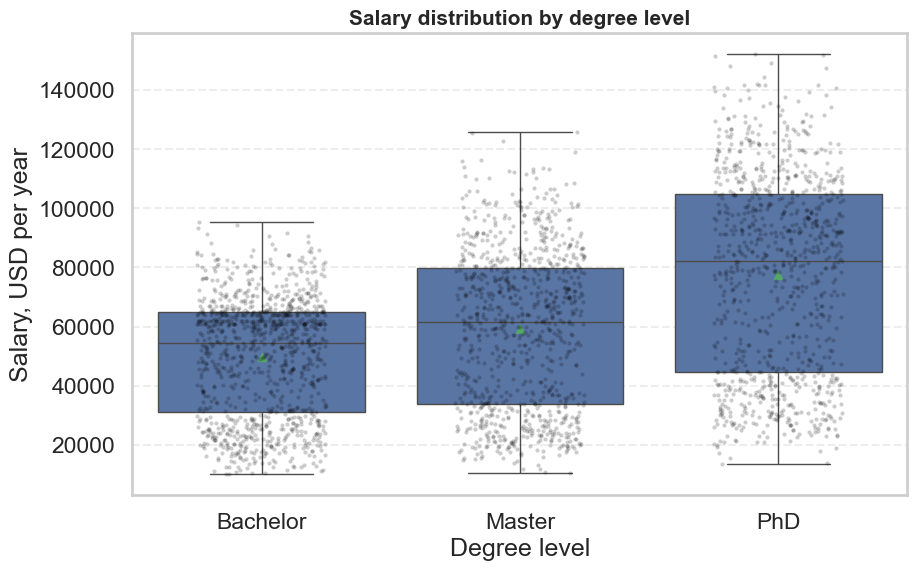

In [698]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=analysis_data,
    x="Degree",
    y=salary_col,
    order=degree_order,
    showmeans=True
)

sns.stripplot(
    data=analysis_data,
    x="Degree",
    y=salary_col,
    order=degree_order,
    color="black",
    alpha=0.2,
    jitter=0.25,
    size=3
)

plt.title("Salary distribution by degree level", fontsize=15, weight="bold")
plt.xlabel("Degree level")
plt.ylabel("Salary, USD per year")
plt.grid(axis="y", linestyle="--", alpha=0.35)
plt.show()

The table and boxplot compare salary distributions across Bachelor, Master, and PhD graduates.

The boxplot shows not only average salary differences, but also spread and outliers. This is important because two degree levels may have similar average salaries but very different salary distributions.

In [699]:
salary_by_field = (
    analysis_data
    .groupby("Field")[salary_col]
    .agg(
        number_of_graduates="count",
        mean_salary="mean",
        median_salary="median",
        salary_std="std",
        min_salary="min",
        max_salary="max"
    )
    .sort_values("median_salary", ascending=False)
    .round(2)
)

salary_by_field

,number_of_graduates,mean_salary,median_salary,salary_std,min_salary,max_salary
Field,,,,,,
Healthcare & Medicine,383,67657.44,68600.0,31345.76,16200,149100
IT,909,68621.78,65000.0,30827.74,10300,152200
Business & Finance,377,62995.23,63900.0,32261.74,10700,141600
Engineering,469,61233.48,62000.0,25851.66,10200,135500
Natural Sciences,395,52269.87,52500.0,24517.50,11300,114400
Social Sciences,397,48352.64,48600.0,21176.23,10100,100700


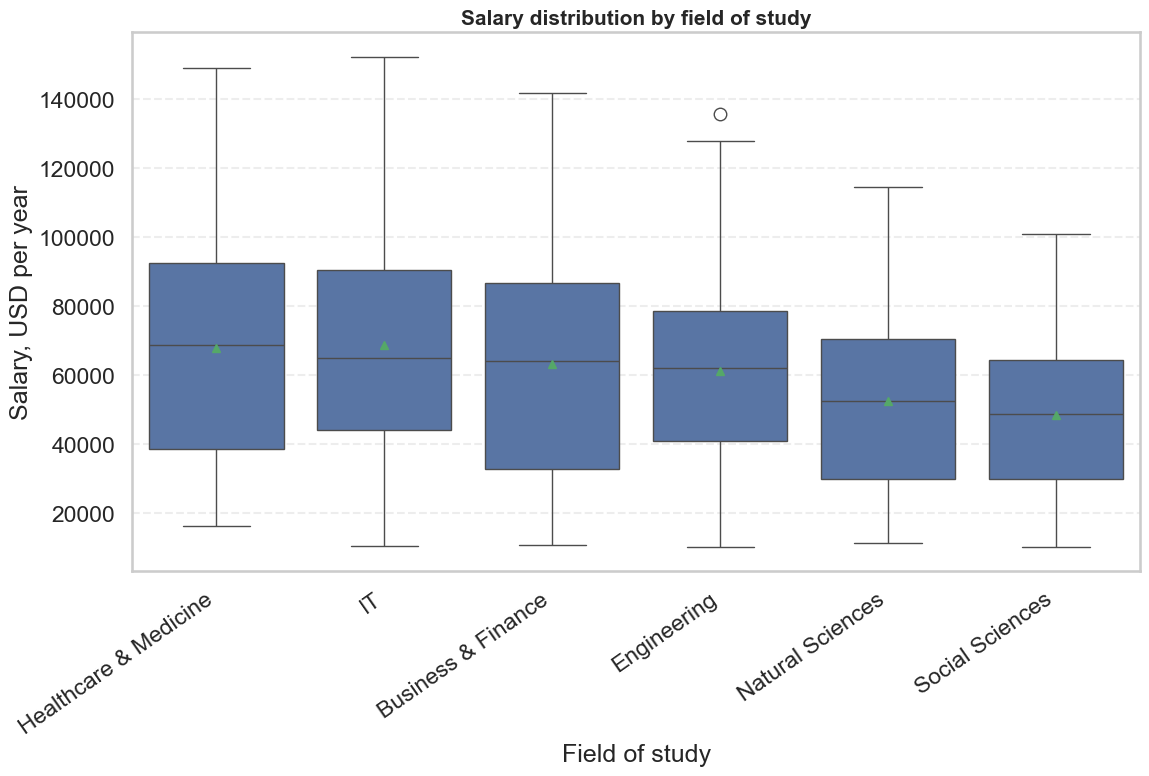

In [700]:
field_order = (
    analysis_data
    .groupby("Field")[salary_col]
    .median()
    .sort_values(ascending=False)
    .index
)

plt.figure(figsize=(13, 7))

sns.boxplot(
    data=analysis_data,
    x="Field",
    y=salary_col,
    order=field_order,
    showmeans=True
)

plt.title("Salary distribution by field of study", fontsize=15, weight="bold")
plt.xlabel("Field of study")
plt.ylabel("Salary, USD per year")
plt.xticks(rotation=35, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.35)
plt.show()

The field comparison shows whether salary differences may be connected with specialization. This is important because degree level alone may not explain salary differences if some fields are generally associated with higher salaries than others.

Later, this will help us check whether the effect of degree level remains visible after accounting for field of study.

In [701]:
salary_by_rank_group = (
    analysis_data
    .groupby("Rank Group", observed=True)[salary_col]
    .agg(
        number_of_graduates="count",
        mean_salary="mean",
        median_salary="median",
        salary_std="std",
        min_salary="min",
        max_salary="max"
    )
    .round(2)
)

salary_by_rank_group

,number_of_graduates,mean_salary,median_salary,salary_std,min_salary,max_salary
Rank Group,,,,,,
Top 10,294,92681.29,90600.0,23897.85,44100,152200
11-50,622,75748.55,74100.0,20794.94,29200,130500
51-100,580,56883.79,52450.0,27623.61,11900,138200
101-300,1173,49862.15,43300.0,27669.19,10100,141700
301+,261,56534.48,56700.0,24480.60,10900,121400


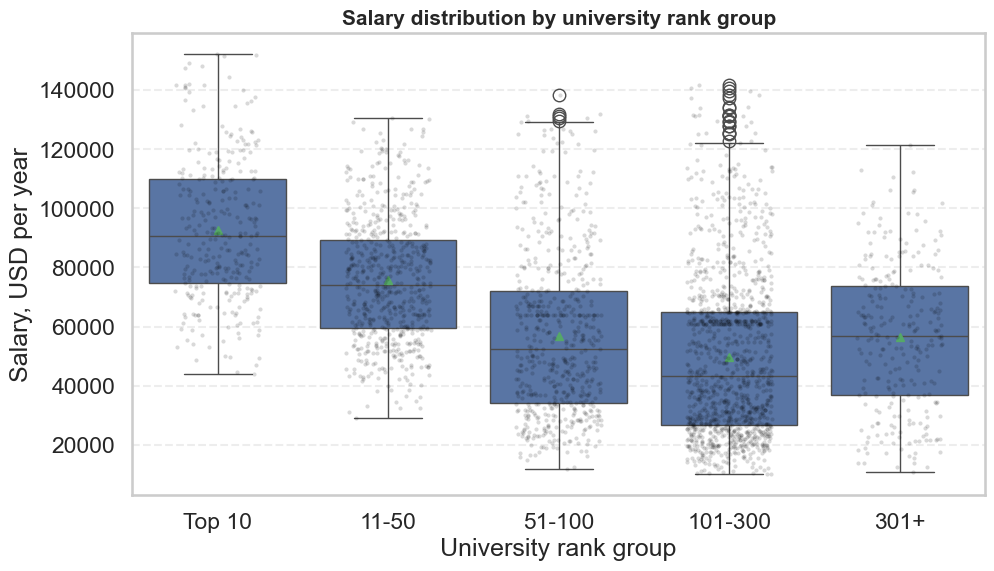

In [702]:
plt.figure(figsize=(11, 6))

sns.boxplot(
    data=analysis_data,
    x="Rank Group",
    y=salary_col,
    order=rank_labels,
    showmeans=True
)

sns.stripplot(
    data=analysis_data,
    x="Rank Group",
    y=salary_col,
    order=rank_labels,
    color="black",
    alpha=0.15,
    jitter=0.25,
    size=3
)

plt.title("Salary distribution by university rank group", fontsize=15, weight="bold")
plt.xlabel("University rank group")
plt.ylabel("Salary, USD per year")
plt.grid(axis="y", linestyle="--", alpha=0.35)
plt.show()

This comparison shows whether graduates from higher-ranked universities tend to have different salary distributions.

Rank groups are easier to interpret than raw rank values. They also reduce the visual distortion caused by unevenly distributed university rankings.

In [703]:
salary_by_degree_and_field = (
    analysis_data
    .groupby(["Degree", "Field"], observed=True)[salary_col]
    .agg(
        number_of_graduates="count",
        mean_salary="mean",
        median_salary="median",
        salary_std="std"
    )
    .sort_values("median_salary", ascending=False)
    .round(2)
)

salary_by_degree_and_field

number_of_graduates  mean_salary  \
Degree   Field                                                     
PhD      IT                                     277     88492.06   
         Healthcare & Medicine                  129     82813.95   
         Business & Finance                     144     80141.67   
         Engineering                            126     76825.40   
Master   IT                                     252     66562.70   
PhD      Natural Sciences                       134     63825.37   
Master   Healthcare & Medicine                  126     67950.00   
         Business & Finance                     111     61470.27   
PhD      Social Sciences                        133     60828.57   
Master   Engineering                            140     59089.29   
Bachelor IT                                     380     55502.89   
         Engineering                            203     53034.48   
Master   Natural Sciences                       144     50167.36   
Bachelor Healthcare & Medicine                  128     52094.53   
Master   Social Sciences                        142     45918.31   
Bachelor Natural Sciences                       117     41623.08   
         Social Sciences                        122     37585.25   
         Business & Finance                     122     44144.26   

                                median_salary  salary_std  
Degree   Field                                             
PhD      IT                           98500.0    35166.65  
         Healthcare & Medicine        92800.0    34790.69  
         Business & Finance           91450.0    35122.31  
         Engineering                  84250.0    30636.10  
Master   IT                           73100.0    28286.70  
PhD      Natural Sciences             71600.0    27829.13  
Master   Healthcare & Medicine        71350.0    28449.05  
         Business & Finance           70100.0    25335.86  
PhD      Social Sciences              67000.0    22335.78  
Master   Engineering                  64150.0    25330.26  
Bachelor IT                           62000.0    19554.40  
         Engineering                  61000.0    17425.92  
Master   Natural Sciences             55400.0    22578.63  
Bachelor Healthcare & Medicine        54550.0    21478.99  
Master   Social Sciences              51400.0    18883.33  
Bachelor Natural Sciences             45100.0    15849.66  
         Social Sciences              42200.0    14591.25  
         Business & Finance           41750.0    21967.15

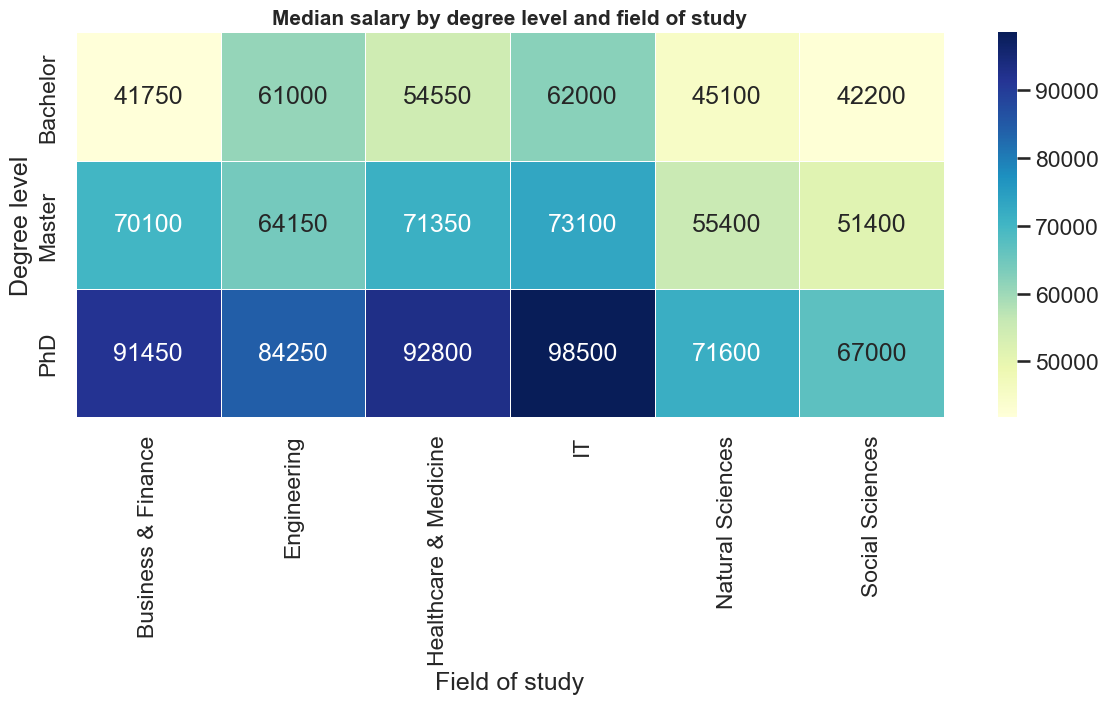

In [704]:
degree_field_median_salary = analysis_data.pivot_table(
    index="Degree",
    columns="Field",
    values=salary_col,
    aggfunc="median",
    observed=True
)

plt.figure(figsize=(14, 5))

sns.heatmap(
    degree_field_median_salary,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu",
    linewidths=0.5
)

plt.title("Median salary by degree level and field of study", fontsize=15, weight="bold")
plt.xlabel("Field of study")
plt.ylabel("Degree level")
plt.show()

The heatmap combines degree level and field of study. This gives a more detailed view than analyzing degree or field separately.

This comparison is important because salary differences may depend on combinations of factors. For example, a Master's degree may be associated with a larger salary difference in some fields than in others.

### Summary of detailed overview

The detailed overview shows that salary should not be analyzed using only one variable. Degree level, field of study, and university ranking may all be connected with salary differences.

These results motivate the next section of the project, where we will formulate and test statistical hypotheses about salary factors.

## 5. Hypothesis checking

### Hypothesis 1: Degree level is associated with graduate salary

In this section, we check the assumption that graduates with higher degree levels tend to have higher salaries.

We do not use formal statistical tests here. Instead, we compare degree groups using descriptive statistics and visualizations:

1. average salary,
2. median salary,
3. salary distribution,
4. salary relative to the median salary in the same field of study.

The last metric is useful because salaries may strongly depend on the field of study. For example, graduates from IT or Engineering may have different typical salaries than graduates from other fields.


In [705]:
h1_metric_col = "Salary Relative to Field Median"

h1_data = analysis_data.dropna(
    subset=["Degree", "Field", salary_col, h1_metric_col]
).copy()

h1_data = h1_data[
    h1_data["Degree"].isin(degree_order)
].copy()

h1_data["Degree"] = pd.Categorical(
    h1_data["Degree"],
    categories=degree_order,
    ordered=True
)

degree_salary_check = (
    h1_data
    .groupby("Degree", observed=True)
    .agg(
        number_of_graduates=(salary_col, "count"),
        mean_salary=(salary_col, "mean"),
        median_salary=(salary_col, "median"),
        mean_relative_salary=(h1_metric_col, "mean"),
        median_relative_salary=(h1_metric_col, "median")
    )
    .round(3)
)

degree_salary_check["median_salary_premium_percent"] = (
    (degree_salary_check["median_relative_salary"] - 1) * 100
).round(2)

degree_salary_check

,number_of_graduates,mean_salary,median_salary,mean_relative_salary,median_relative_salary,median_salary_premium_percent
Degree,,,,,,
Bachelor,1072,49781.810,54400.0,0.809,0.918,-8.2
Master,915,59208.415,61600.0,0.978,1.077,7.7
PhD,943,77474.549,82300.0,1.271,1.414,41.4


The table compares salaries by degree level. Raw salary values show direct salary differences between Bachelor, Master, and PhD graduates.

The relative salary columns compare each graduate's salary with the median salary in the same field of study. A value above `1.0` means that graduates of this degree level tend to earn more than the median salary in their field. A value below `1.0` means the opposite.

This helps us check whether degree level is associated with salary even when field differences are partially taken into account.


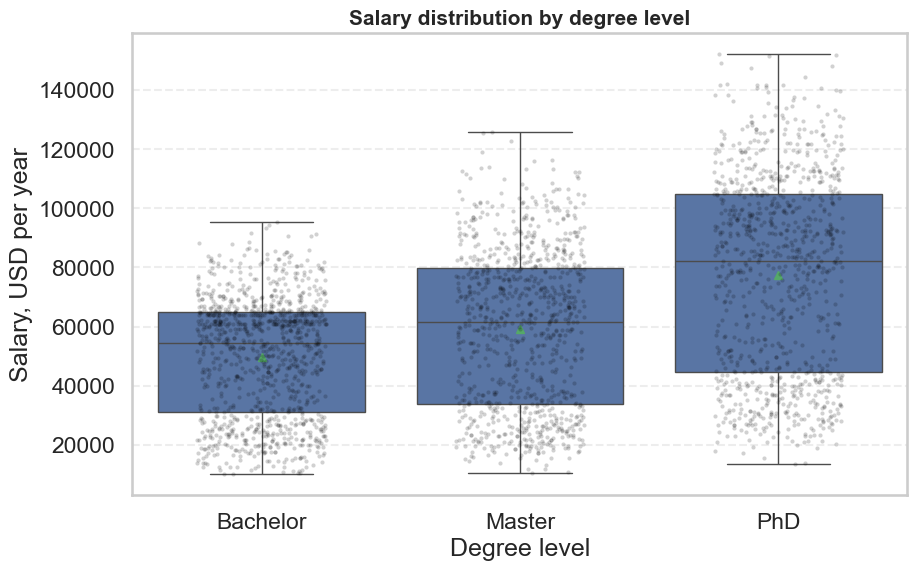

In [706]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=h1_data,
    x="Degree",
    y=salary_col,
    order=degree_order,
    showmeans=True
)

sns.stripplot(
    data=h1_data,
    x="Degree",
    y=salary_col,
    order=degree_order,
    color="black",
    alpha=0.18,
    jitter=0.25,
    size=3
)

plt.title("Salary distribution by degree level", fontsize=15, weight="bold")
plt.xlabel("Degree level")
plt.ylabel("Salary, USD per year")
plt.grid(axis="y", linestyle="--", alpha=0.35)
plt.show()

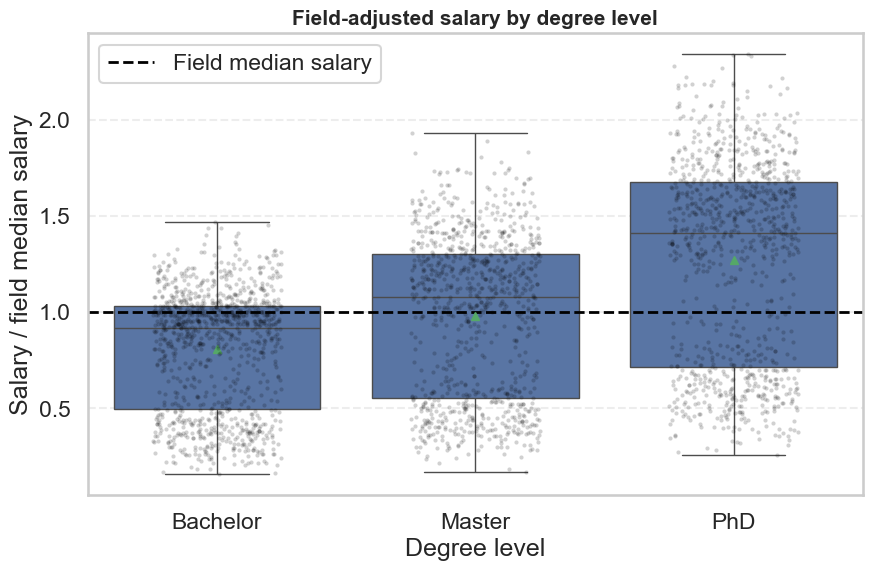

In [707]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=h1_data,
    x="Degree",
    y=h1_metric_col,
    order=degree_order,
    showmeans=True
)

sns.stripplot(
    data=h1_data,
    x="Degree",
    y=h1_metric_col,
    order=degree_order,
    color="black",
    alpha=0.18,
    jitter=0.25,
    size=3
)

plt.axhline(
    1.0,
    color="black",
    linestyle="--",
    linewidth=2,
    label="Field median salary"
)

plt.title("Field-adjusted salary by degree level", fontsize=15, weight="bold")
plt.xlabel("Degree level")
plt.ylabel("Salary / field median salary")
plt.grid(axis="y", linestyle="--", alpha=0.35)
plt.legend()
plt.show()

In [708]:
bachelor_median = degree_salary_check.loc["Bachelor", "median_relative_salary"]
master_median = degree_salary_check.loc["Master", "median_relative_salary"]
phd_median = degree_salary_check.loc["PhD", "median_relative_salary"]

print("Hypothesis 1 conclusion")
print("-" * 30)

print(f"Bachelor median relative salary: {bachelor_median:.3f}")
print(f"Master median relative salary: {master_median:.3f}")
print(f"PhD median relative salary: {phd_median:.3f}")

print()

if bachelor_median < master_median < phd_median:
    print(
        "The data supports the assumption that higher degree levels are associated "
        "with higher field-adjusted salaries."
    )
elif bachelor_median < master_median:
    print(
        "The data partially supports the assumption: Master's graduates have higher "
        "field-adjusted salaries than Bachelor's graduates, but the pattern is not strictly increasing for all degrees."
    )
else:
    print(
        "The data does not clearly support a simple increasing relationship between degree level and field-adjusted salary."
    )

print(
    "This result should be interpreted as an observed association, not as proof that the degree itself causes higher salary."
)

Hypothesis 1 conclusion
------------------------------
Bachelor median relative salary: 0.918
Master median relative salary: 1.077
PhD median relative salary: 1.414

The data supports the assumption that higher degree levels are associated with higher field-adjusted salaries.
This result should be interpreted as an observed association, not as proof that the degree itself causes higher salary.


The comparison suggests whether degree level is associated with salary in this dataset. We use both raw salary and field-adjusted salary because different fields may have different typical salary levels.

If higher degree levels have higher median relative salary values, this supports the assumption that degree level is connected with salary. However, this does not prove causality. Salary may also depend on university, field, country, industry, work experience, and individual skills.


### Hypothesis 2: University ranking is associated with graduate salary

In this section, we check whether graduates from higher-ranked universities tend to have higher salaries.

A lower university rank number means a better position in the ranking. Therefore, if the assumption is correct, we expect salaries to be higher for universities with better ranking positions.

We do not use formal statistical tests here. Instead, we compare:

1. median salary by university rank group,
2. average salary by university rank group,
3. the visual relationship between university rank and salary.

Because university ranks are unevenly distributed, we use `Log University Rank` for the scatterplot.

In [709]:
h2_data = analysis_data.dropna(
    subset=["University", "Degree", salary_col, rank_col, "Log University Rank", "Rank Group"]
).copy()

h2_data = h2_data[
    (h2_data[salary_col] > 0) &
    (h2_data[rank_col] > 0)
].copy()

h2_data.head()

,University,Degree,Field,Salary (USD per year),University Rate,Degree Code,Log University Rank,Salary Relative to Field Median,Salary Percentile,Rank Group
0,Harvard University,Bachelor,IT,60000,1,1,0.000000,0.923077,47.508532,Top 10
1,Massachusetts Institute of Technology,Bachelor,Engineering,65000,3,1,0.477121,1.048387,57.098976,Top 10
2,Stanford University,Bachelor,Engineering,58000,2,1,0.301030,0.935484,45.255973,Top 10
3,University of Rochester,Bachelor,IT,61000,105,1,2.021189,0.938462,49.215017,101-300
4,University of Connecticut,Bachelor,Engineering,61000,193,1,2.285557,0.983871,49.215017,101-300


In [710]:
rank_salary_check = (
    h2_data
    .groupby("Rank Group", observed=True)
    .agg(
        number_of_graduates=(salary_col, "count"),
        number_of_universities=("University", "nunique"),
        mean_salary=(salary_col, "mean"),
        median_salary=(salary_col, "median"),
        min_salary=(salary_col, "min"),
        max_salary=(salary_col, "max")
    )
    .round(2)
)

rank_salary_check

,number_of_graduates,number_of_universities,mean_salary,median_salary,min_salary,max_salary
Rank Group,,,,,,
Top 10,294,4,92681.29,90600.0,44100,152200
11-50,622,8,75748.55,74100.0,29200,130500
51-100,580,9,56883.79,52450.0,11900,138200
101-300,1173,15,49862.15,43300.0,10100,141700
301+,261,3,56534.48,56700.0,10900,121400


The table compares graduate salaries across university rank groups. This gives a simple overview of whether salaries are generally higher for graduates from better-ranked universities.

Median salary is especially useful because it is less affected by very high or very low salary values.

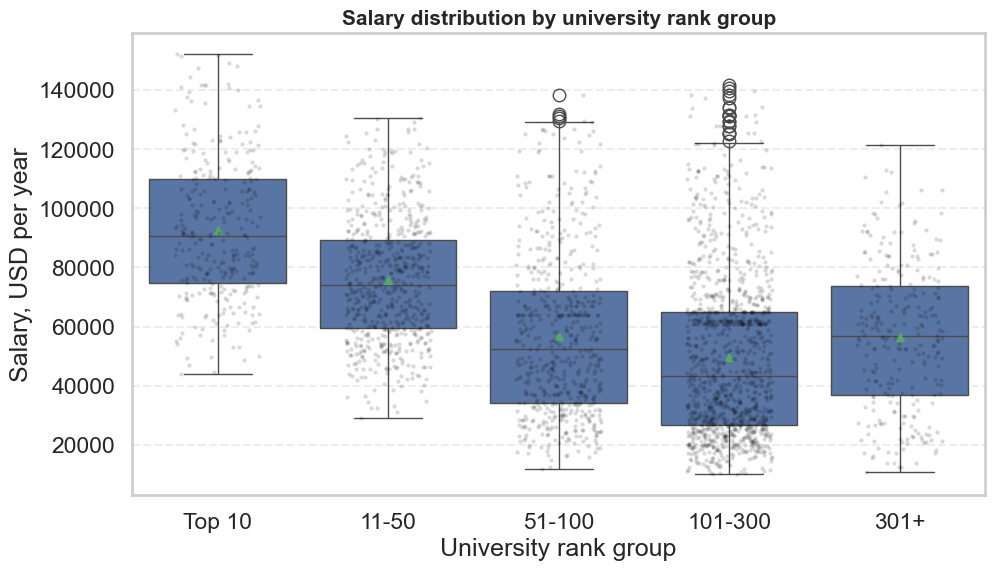

In [736]:
plt.figure(figsize=(11, 6))

sns.boxplot(
    data=h2_data,
    x="Rank Group",
    y=salary_col,
    order=rank_labels,
    showmeans=True
)

sns.stripplot(
    data=h2_data,
    x="Rank Group",
    y=salary_col,
    order=rank_labels,
    color="black",
    alpha=0.15,
    jitter=0.25,
    size=3
)

plt.title("Salary distribution by university rank group", fontsize=15, weight="bold")
plt.xlabel("University rank group")
plt.ylabel("Salary, USD per year")
plt.grid(axis="y", linestyle="--", alpha=0.35)
plt.show()

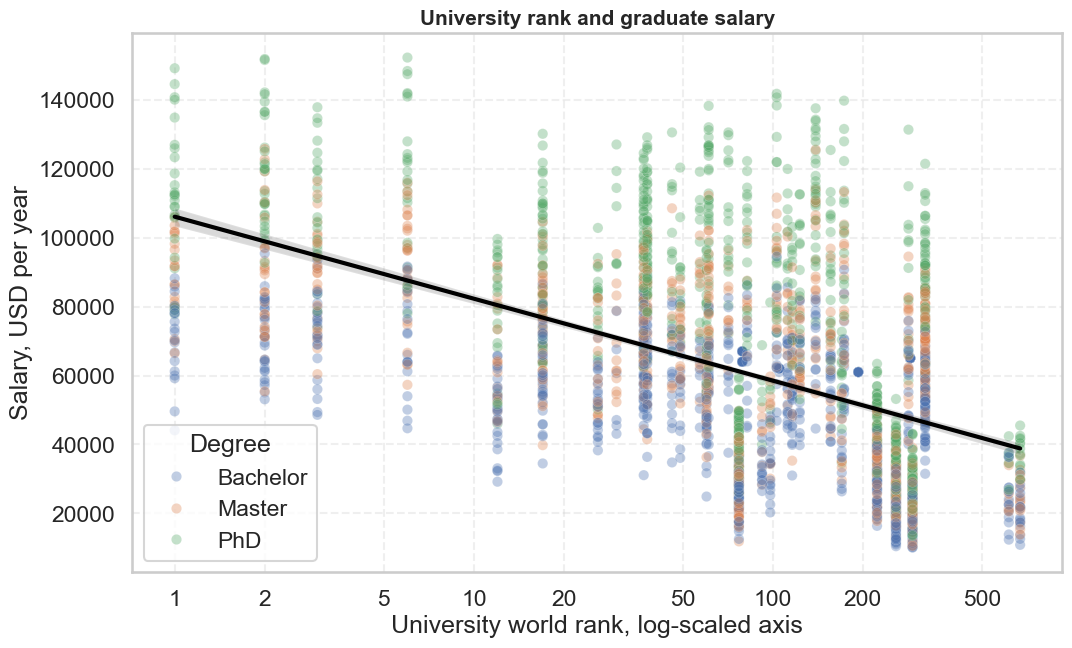

In [737]:
plt.figure(figsize=(12, 7))

ax = sns.scatterplot(
    data=h2_data,
    x="Log University Rank",
    y=salary_col,
    hue="Degree",
    alpha=0.35,
    s=55,
    edgecolor="white",
    linewidth=0.3
)

sns.regplot(
    data=h2_data,
    x="Log University Rank",
    y=salary_col,
    scatter=False,
    color="black",
    line_kws={
        "linewidth": 3,
        "label": "General trend"
    }
)

rank_ticks = np.array([1, 2, 5, 10, 20, 50, 100, 200, 500, 1000])
rank_ticks = rank_ticks[
    (rank_ticks >= h2_data[rank_col].min()) &
    (rank_ticks <= h2_data[rank_col].max())
]

ax.set_xticks(np.log10(rank_ticks))
ax.set_xticklabels(rank_ticks)

plt.title("University rank and graduate salary", fontsize=15, weight="bold")
plt.xlabel("University world rank, log-scaled axis")
plt.ylabel("Salary, USD per year")
plt.grid(axis="both", linestyle="--", alpha=0.3)
plt.legend(title="Degree")
plt.show()

In [738]:
rank_salary_correlation = h2_data[["Log University Rank", salary_col]].corr().iloc[0, 1]

print("Hypothesis 2 conclusion")
print("-" * 30)

print(f"Correlation between log university rank and salary: {rank_salary_correlation:.3f}")

print()

if rank_salary_correlation < -0.3:
    print(
        "The data supports the assumption that graduates from higher-ranked universities "
        "tend to have higher salaries. The relationship is negative because lower rank values "
        "mean better universities."
    )
elif rank_salary_correlation < 0:
    print(
        "The data partially supports the assumption. There is a negative relationship, "
        "but it is not very strong."
    )
else:
    print(
        "The data does not clearly support the assumption that better-ranked universities "
        "are associated with higher salaries."
    )

print(
    "This result should be interpreted as an observed association, not as proof that university rank causes higher salary."
)

Hypothesis 2 conclusion
------------------------------
Correlation between log university rank and salary: -0.517

The data supports the assumption that graduates from higher-ranked universities tend to have higher salaries. The relationship is negative because lower rank values mean better universities.
This result should be interpreted as an observed association, not as proof that university rank causes higher salary.


The comparison suggests whether university ranking is associated with graduate salary in this dataset.

The rank group table and boxplot give a simple comparison between different university ranking categories. The scatterplot gives a more detailed view using the log-scaled rank variable.

If the correlation is negative, it means that better-ranked universities tend to be associated with higher salaries, because smaller rank values represent better universities. However, this relationship should not be interpreted as causation. Salary may also depend on degree level, field of study, country, industry, work experience, and individual skills.

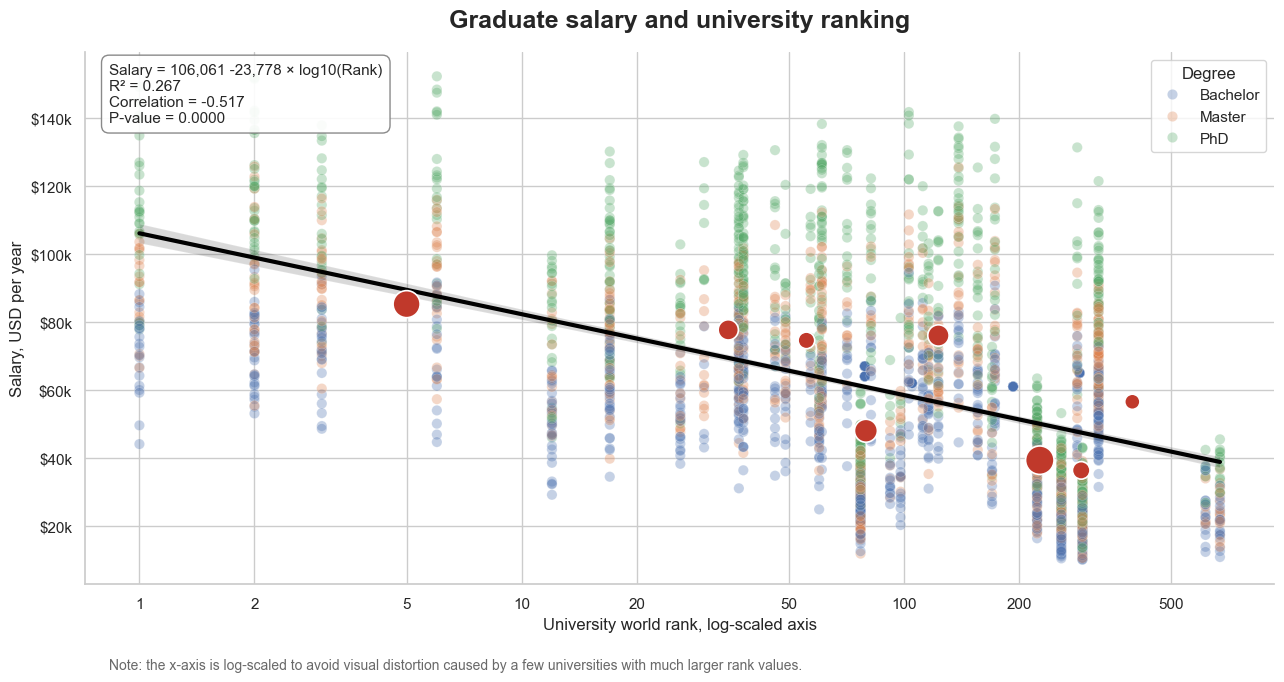

In [711]:
# Improved linear regression representation:
# salary ~ log10(university rank)
# This avoids a huge empty area when university ranks are unevenly distributed.

from matplotlib.ticker import FuncFormatter

salary_col = "Salary (USD per year)"
rank_col = "University Rate"

regression_data = alumni_data[[rank_col, salary_col, "Degree"]].copy()

regression_data[rank_col] = pd.to_numeric(regression_data[rank_col], errors="coerce")
regression_data[salary_col] = pd.to_numeric(regression_data[salary_col], errors="coerce")

regression_data = regression_data.dropna(subset=[rank_col, salary_col, "Degree"])
regression_data = regression_data[
    (regression_data[rank_col] > 0) &
    (regression_data[salary_col] > 0)
]

# Log-transform rank to reduce empty space on the right side.
regression_data["Log University Rank"] = np.log10(regression_data[rank_col])

x = regression_data["Log University Rank"]
y = regression_data[salary_col]

slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

# Grouped averages for clearer visual trend
regression_data["Rank group"] = pd.qcut(
    regression_data[rank_col],
    q=8,
    duplicates="drop"
)

rank_summary = (
    regression_data
    .groupby("Rank group", observed=True)
    .agg(
        mean_rank=(rank_col, "mean"),
        mean_log_rank=("Log University Rank", "mean"),
        mean_salary=(salary_col, "mean"),
        observations=(salary_col, "size")
    )
    .reset_index()
)

sns.set_theme(style="whitegrid", context="notebook")

fig, ax = plt.subplots(figsize=(13, 7))

# Individual observations
sns.scatterplot(
    data=regression_data,
    x="Log University Rank",
    y=salary_col,
    hue="Degree",
    alpha=0.32,
    s=55,
    edgecolor="white",
    linewidth=0.35,
    ax=ax
)

# Regression line
sns.regplot(
    data=regression_data,
    x="Log University Rank",
    y=salary_col,
    scatter=False,
    ci=95,
    color="black",
    line_kws={
        "linewidth": 3,
        "label": "Linear regression"
    },
    ax=ax
)

# Grouped average points
sns.scatterplot(
    data=rank_summary,
    x="mean_log_rank",
    y="mean_salary",
    size="observations",
    sizes=(120, 420),
    color="#C0392B",
    edgecolor="white",
    linewidth=1.2,
    legend=False,
    ax=ax,
    zorder=5
)

ax.set_title(
    "Graduate salary and university ranking",
    fontsize=18,
    weight="bold",
    pad=18
)

ax.set_xlabel(
    "University world rank, log-scaled axis",
    fontsize=12
)

ax.set_ylabel(
    "Salary, USD per year",
    fontsize=12
)

ax.yaxis.set_major_formatter(
    FuncFormatter(lambda value, position: f"${value / 1000:.0f}k")
)

# Show original rank values on the x-axis, not log values
rank_ticks = np.array([1, 2, 5, 10, 20, 50, 100, 200, 500, 1000, 2000])

rank_ticks = rank_ticks[
    (rank_ticks >= regression_data[rank_col].min()) &
    (rank_ticks <= regression_data[rank_col].max())
]

ax.set_xticks(np.log10(rank_ticks))
ax.set_xticklabels(rank_ticks)

equation_text = (
    f"Salary = {intercept:,.0f} {slope:+,.0f} × log10(Rank)\n"
    f"R² = {r_value ** 2:.3f}\n"
    f"Correlation = {r_value:.3f}\n"
    f"P-value = {p_value:.4f}"
)

ax.text(
    0.02,
    0.98,
    equation_text,
    transform=ax.transAxes,
    verticalalignment="top",
    bbox={
        "boxstyle": "round,pad=0.5",
        "facecolor": "white",
        "edgecolor": "gray",
        "alpha": 0.92
    },
    fontsize=11
)

ax.text(
    0.02,
    -0.16,
    "Note: the x-axis is log-scaled to avoid visual distortion caused by a few universities with much larger rank values.",
    transform=ax.transAxes,
    fontsize=10,
    color="dimgray"
)

ax.legend(
    title="Degree",
    frameon=True,
    loc="upper right"
)

sns.despine()
plt.tight_layout()
plt.show()

In [712]:
print("Regression interpretation")
print("-" * 30)

print(f"Slope: {slope:,.2f}")
print(f"R-squared: {r_value ** 2:.3f}")
print(f"Correlation coefficient: {r_value:.3f}")
print(f"P-value: {p_value:.5f}")

print()

if slope < 0:
    print(
        "The regression slope is negative. Since lower university rank values represent better-ranked universities, "
        "this suggests that graduates from higher-ranked universities tend to have higher salaries in this dataset."
    )
elif slope > 0:
    print(
        "The regression slope is positive. This suggests that salary tends to increase as rank values become larger, "
        "so university rank alone may not explain salary differences well."
    )
else:
    print(
        "The slope is close to zero, so there is no clear linear relationship between university rank and salary."
    )

print()
print(
    "The model uses log10(rank), not raw rank. This makes the visualization more balanced when ranks are unevenly distributed."
)

Regression interpretation
------------------------------
Slope: -23,777.67
R-squared: 0.267
Correlation coefficient: -0.517
P-value: 0.00000

The regression slope is negative. Since lower university rank values represent better-ranked universities, this suggests that graduates from higher-ranked universities tend to have higher salaries in this dataset.

The model uses log10(rank), not raw rank. This makes the visualization more balanced when ranks are unevenly distributed.


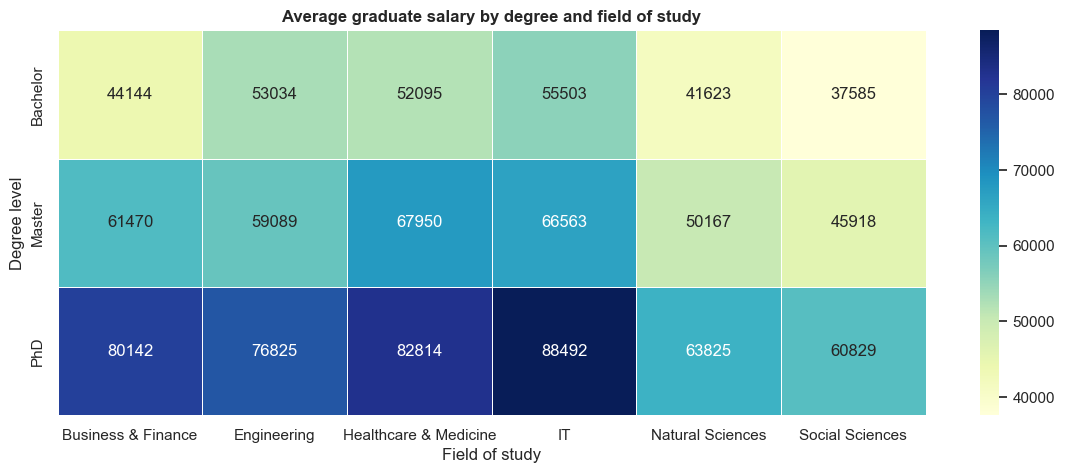

In [713]:
salary_heatmap = analysis_data.pivot_table(
    index="Degree",
    columns="Field",
    values=salary_col,
    aggfunc="mean"
)

plt.figure(figsize=(14, 5))

sns.heatmap(
    salary_heatmap,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu",
    linewidths=0.5
)

plt.title("Average graduate salary by degree and field of study")
plt.xlabel("Field of study")
plt.ylabel("Degree level")
plt.show()

In [714]:
degree_field_summary = (
    analysis_data
    .groupby(["Degree", "Field"])
    .agg(
        average_salary=(salary_col, "mean"),
        median_salary=(salary_col, "median"),
        number_of_graduates=(salary_col, "count")
    )
    .reset_index()
    .sort_values("average_salary", ascending=False)
)

degree_field_summary

,Degree,Field,average_salary,median_salary,number_of_graduates
15,PhD,IT,88492.057762,98500.0,277
14,PhD,Healthcare & Medicine,82813.953488,92800.0,129
12,PhD,Business & Finance,80141.666667,91450.0,144
13,PhD,Engineering,76825.396825,84250.0,126
8,Master,Healthcare & Medicine,67950.000000,71350.0,126
9,Master,IT,66562.698413,73100.0,252
16,PhD,Natural Sciences,63825.373134,71600.0,134
6,Master,Business & Finance,61470.270270,70100.0,111
17,PhD,Social Sciences,60828.571429,67000.0,133
7,Master,Engineering,59089.285714,64150.0,140


In [715]:
alumni_data["Salary (USD per year)"].describe()

count      2930.000000
mean      61638.327645
std       29334.873890
min       10100.000000
25%       36700.000000
50%       61200.000000
75%       81275.000000
max      152200.000000
Name: Salary (USD per year), dtype: float64

In [716]:
alumni_data.University.unique()

<StringArray>
[                      'Harvard University',
    'Massachusetts Institute of Technology',
                      'Stanford University',
                  'University of Rochester',
                'University of Connecticut',
                   'University of Delaware',
                   'University of Virginia',
    'Indian Institute of Technology Bombay',
                  'University of Cape Town',
                     'Karolinska Institute',
                  'University of Amsterdam',
                  'Imperial College London',
 'National Autonomous University of Mexico',
           'Hebrew University of Jerusalem',
            'Royal Institute of Technology',
                'Seoul National University',
         'National University of Singapore',
                  'University of São Paulo',
                    'University of Toronto',
           'Australian National University',
               'University of Buenos Aires',
                'King Abdulaziz Universit

In [717]:
mean_salary = alumni_data.groupby("University")["Salary (USD per year)"].mean()
mean_salary

University
Australian National University              83602.380952
Delft University of Technology              69324.000000
Fudan University                            47127.272727
Georgia Institute of Technology             95790.476190
Harvard University                          93052.307692
Hebrew University of Jerusalem              84912.631579
Heidelberg University                       76066.666667
Imperial College London                     76472.000000
Indian Institute of Technology Bombay       27331.034483
Indian Institute of Technology Delhi        26978.723404
Karolinska Institute                        70449.019608
King Abdulaziz University                   68621.081081
Kyoto University                            65039.285714
Massachusetts Institute of Technology       89295.890411
McGill University                           78905.147059
Nanyang Technological University            83616.000000
National Autonomous University of Mexico    27512.970711
National University 

In [718]:
mean_salary_uni_deg = alumni_data.groupby(["University", "Degree"])["Salary (USD per year)"].mean()
mean_salary_uni_field = alumni_data.groupby(["University", "Field"])["Salary (USD per year)"].mean()
mean_salary_uni_deg

University                      Degree  
Australian National University  Bachelor    64985.714286
                                Master      83633.333333
                                PhD         97305.263158
Delft University of Technology  Bachelor    55929.411765
                                Master      68047.619048
                                                ...     
University of Toronto           PhD         94095.652174
University of Virginia          Bachelor    64785.714286
École Polytechnique             Bachelor    53495.454545
                                Master      66128.571429
                                PhD         83780.000000
Name: Salary (USD per year), Length: 109, dtype: float64

In [719]:
mean_salary_uni_field

University                      Field                
Australian National University  Business & Finance       95475.000000
                                Engineering              85454.545455
                                Healthcare & Medicine    93600.000000
                                IT                       95755.555556
                                Natural Sciences         70833.333333
                                                             ...     
École Polytechnique             Engineering              63833.333333
                                Healthcare & Medicine    79166.666667
                                IT                       67015.000000
                                Natural Sciences         67350.000000
                                Social Sciences          50922.222222
Name: Salary (USD per year), Length: 218, dtype: float64

<Axes: >

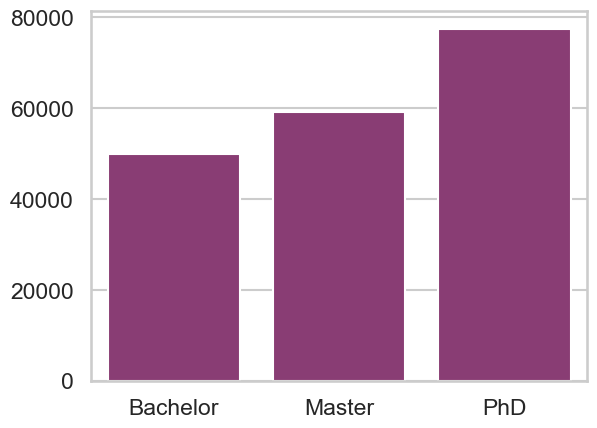

In [720]:
sns.set_theme(style="whitegrid", context="talk")
custom_palette = ["#95317A", "#3da386", "#5b98ed", "#d62728", "#9467bd"]
sns.set_palette(custom_palette)
sns.despine()
sns.barplot({"Bachelor" : alumni_data["Salary (USD per year)"][alumni_data.Degree == "Bachelor"].mean(),
             "Master" : alumni_data["Salary (USD per year)"][alumni_data.Degree == "Master"].mean(),
             "PhD" : alumni_data["Salary (USD per year)"][alumni_data.Degree == "PhD"].mean()})

In [721]:
temp_df = pd.DataFrame({
    'Salary': mean_salary_uni_deg,
    'Rank': mean_salary_uni_deg.index.get_level_values('University').map(rank_dict)
})
temp_df = temp_df.sort_values('Rank', ascending=False)
mean_salary_uni_deg = temp_df['Salary']

In [722]:
mean_salary_uni_deg

University                             Degree  
Indian Institute of Technology Delhi   Master       24581.250000
                                       Bachelor     20594.117647
                                       PhD          37471.428571
Indian Institute of Technology Bombay  PhD          34528.571429
                                       Master       25800.000000
                                                       ...      
Stanford University                    Master       88259.259259
                                       Bachelor     71396.428571
Harvard University                     PhD         111770.370370
                                       Bachelor     70547.368421
                                       Master       88957.894737
Name: Salary, Length: 109, dtype: float64

In [723]:
university_rate[university_rate["Institution"] == "Indian Institute of Technology Delhi"]

,World Rank,Institution,Location,National Rank,Quality of Education,Alumni Employment,Quality of Faculty,Research Output,Quality Publications,Influence,Citations,Score
670,671,Indian Institute of Technology Delhi,India,5,283,95,-,549,634,> 1000,> 1000,72.1


<Figure size 640x480 with 0 Axes>

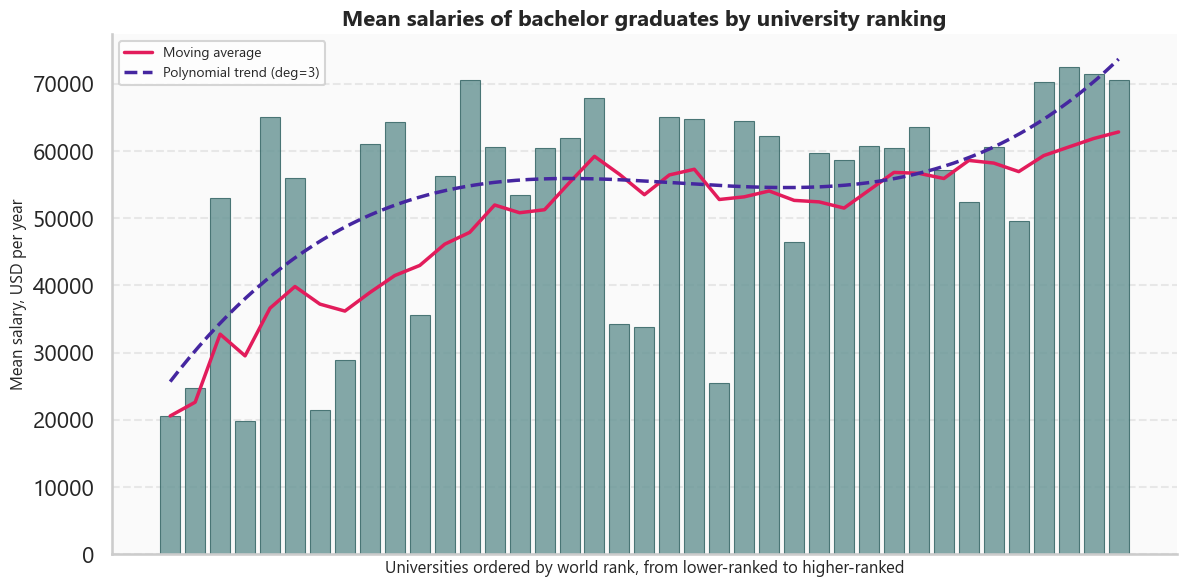

In [724]:
sns.set_theme(style="whitegrid", context="talk")

plt.rcParams['font.family'] = 'Segoe UI'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['xtick.labelsize'] = 9

sns.set_palette("pastel")

sns.despine()
plt.figure(figsize=(12, 6))
sns.barplot(mean_salary_uni_deg[mean_salary_uni_deg.index.get_level_values('Degree') == 'Bachelor'].values, color="#5D9B9B", alpha=0.8, edgecolor='#2C5F5F', linewidth=0.8)

moving_average = pd.Series(mean_salary_uni_deg[mean_salary_uni_deg.index.get_level_values('Degree') == 'Bachelor'].values).rolling(window=10, min_periods=1).mean().values
plt.plot(moving_average, color="#E21C5B", linewidth=2.5, label="Moving average")

x = np.arange(len(mean_salary_uni_deg[mean_salary_uni_deg.index.get_level_values('Degree') == 'Bachelor'].values))
degree = 3
coeffs = np.polyfit(x, mean_salary_uni_deg[mean_salary_uni_deg.index.get_level_values('Degree') == 'Bachelor'].values, degree)
poly = np.poly1d(coeffs)
x_smooth = np.linspace(x.min(), x.max(), 300)
y_smooth = poly(x_smooth)
plt.plot(x_smooth, y_smooth, '--', color="#4526A0", linewidth=2.5, label=f"Polynomial trend (deg={degree})")

plt.xticks([])
plt.xlabel("Universities ordered by world rank, from lower-ranked to higher-ranked")
plt.legend()
plt.ylabel("Mean salary, USD per year")
plt.title("Mean salaries of bachelor graduates by university ranking")

plt.grid(axis='y', linestyle='--', alpha=0.4)
ax = plt.gca()
ax.set_axisbelow(True)
ax.set_facecolor('#FAFAFA')
sns.despine(top=True, right=True)

plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Mean salaries of masters graduated from top universities')

<Figure size 640x480 with 0 Axes>

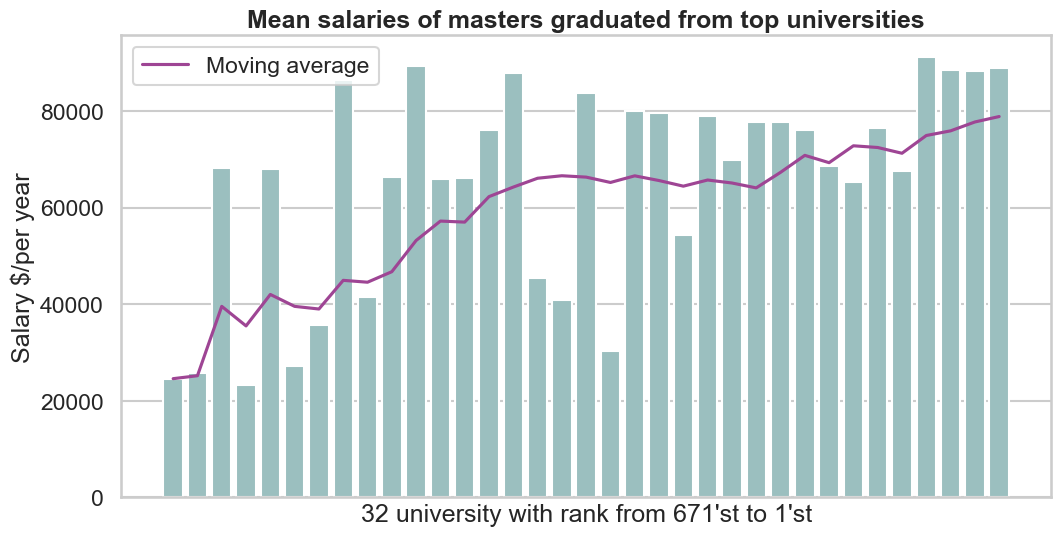

In [725]:
sns.set_theme(style="whitegrid", context="talk")
sns.despine()
plt.figure(figsize=(12, 6))
sns.barplot(mean_salary_uni_deg[mean_salary_uni_deg.index.get_level_values('Degree') == 'Master'].values, color = "#95C5C5")

moving_average = pd.Series(mean_salary_uni_deg[mean_salary_uni_deg.index.get_level_values('Degree') == 'Master'].values).rolling(window=10, min_periods=1).mean().values
plt.plot(moving_average, color = "#9e4594", label = "Moving average")
plt.xticks([])

plt.xlabel("32 university with rank from 671'st to 1'st")
plt.legend()
plt.ylabel("Salary $/per year")
plt.title("Mean salaries of masters graduated from top universities")

Text(0.5, 1.0, 'Mean salaries of masters graduated from top universities')

<Figure size 640x480 with 0 Axes>

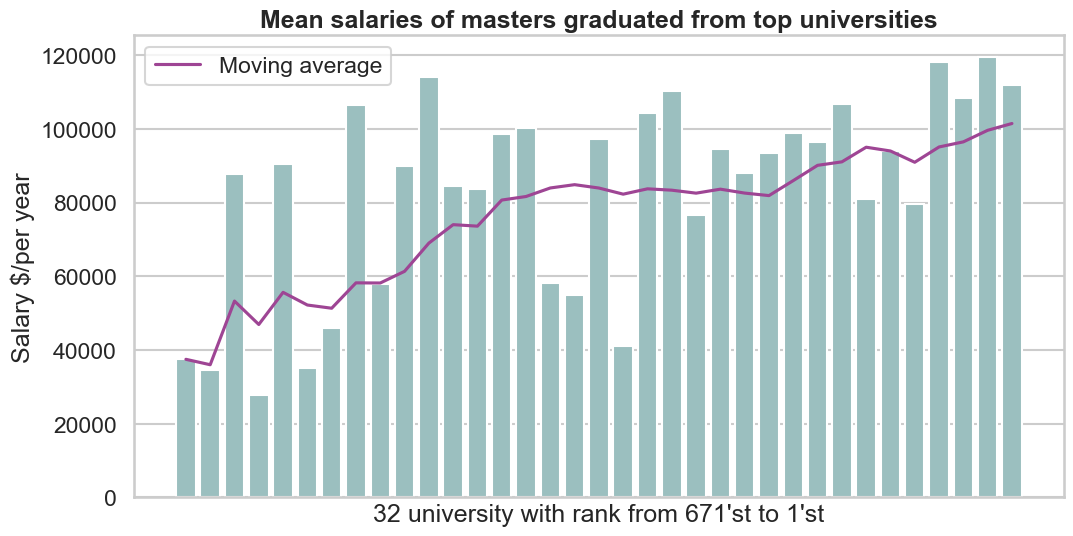

In [726]:
sns.set_theme(style="whitegrid", context="talk")
sns.despine()
plt.figure(figsize=(12, 6))
sns.barplot(mean_salary_uni_deg[mean_salary_uni_deg.index.get_level_values('Degree') == 'PhD'].values, color = "#95C5C5")

moving_average = pd.Series(mean_salary_uni_deg[mean_salary_uni_deg.index.get_level_values('Degree') == 'PhD'].values).rolling(window=10, min_periods=1).mean().values
plt.plot(moving_average, color = "#9e4594", label = "Moving average")
plt.xticks([]) 
plt.xlabel("32 university with rank from 671'st to 1'st")
plt.legend()
plt.ylabel("Salary $/per year")
plt.title("Mean salaries of masters graduated from top universities")

In [727]:
alumni_data

,University,Degree,Field,Salary (USD per year),University Rate
0,Harvard University,Bachelor,IT,60000,1
1,Massachusetts Institute of Technology,Bachelor,Engineering,65000,3
2,Stanford University,Bachelor,Engineering,58000,2
3,University of Rochester,Bachelor,IT,61000,105
4,University of Connecticut,Bachelor,Engineering,61000,193
...,...,...,...,...,...
2925,Royal Institute of Technology,Bachelor,Engineering,64600,156
2926,Karolinska Institute,Bachelor,Business & Finance,55200,49
2927,Hebrew University of Jerusalem,PhD,Social Sciences,62300,61
2928,Kyoto University,Master,IT,52400,26


In [728]:
alumni_data[(alumni_data["Field"] == "IT") & (alumni_data["Degree"] == "Bachelor")]["Salary (USD per year)"].mean()


np.float64(55502.89473684211)

In [729]:
set(alumni_data["Degree"])

{'Bachelor', 'Master', 'PhD'}

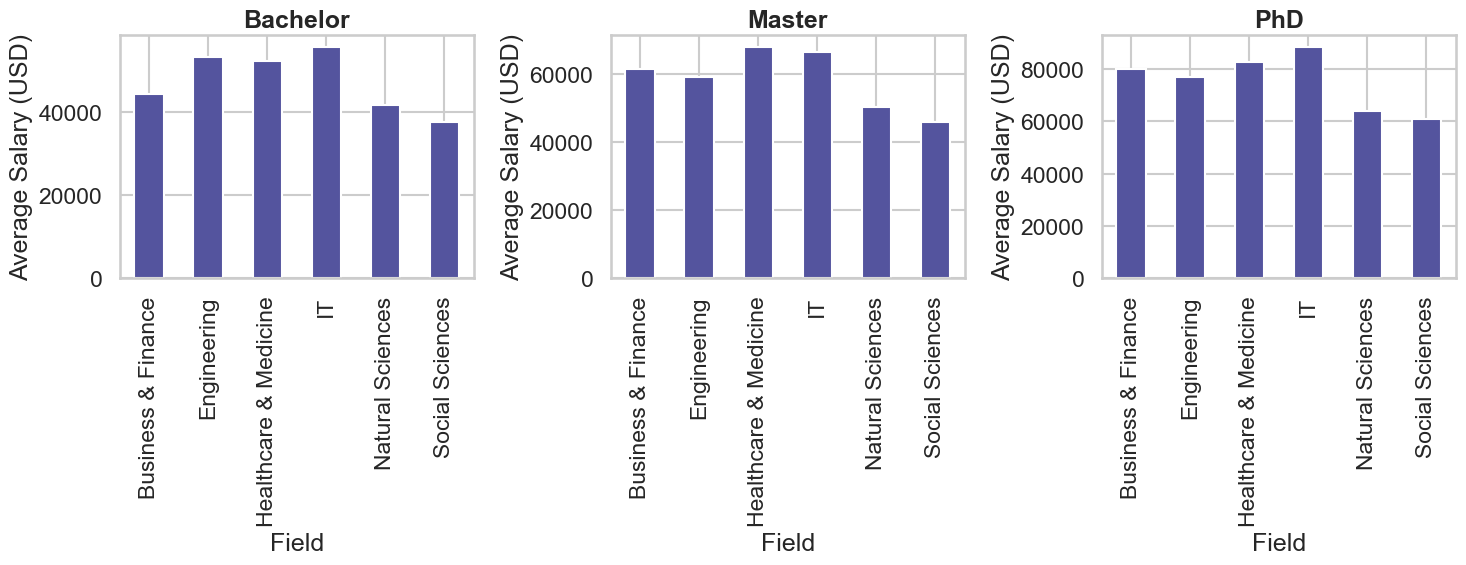

In [730]:
pivot = alumni_data.groupby(['Degree', 'Field'])['Salary (USD per year)'].mean().unstack(level=0)
fig, axes = plt.subplots(1, 3, figsize=(15,6))
for i, degree in enumerate(pivot.columns):
    pivot[degree].plot(kind='bar', ax=axes[i], color="#54549E")
    axes[i].set_title(degree)
    axes[i].set_xlabel('Field')
    axes[i].set_ylabel('Average Salary (USD)')
    axes[i].tick_params(axis='x')
plt.tight_layout()

In [731]:
field_salary = pd.read_csv("degrees-that-pay-back.csv")
field_salary

,Undergraduate Major,Starting Median Salary,Mid-Career Median Salary,Percent change from Starting to Mid-Career Salary,Mid-Career 10th Percentile Salary,Mid-Career 25th Percentile Salary,Mid-Career 75th Percentile Salary,Mid-Career 90th Percentile Salary
0,Accounting,"$46,000.00","$77,100.00",67.6,"$42,200.00","$56,100.00","$108,000.00","$152,000.00"
1,Aerospace Engineering,"$57,700.00","$101,000.00",75.0,"$64,300.00","$82,100.00","$127,000.00","$161,000.00"
2,Agriculture,"$42,600.00","$71,900.00",68.8,"$36,300.00","$52,100.00","$96,300.00","$150,000.00"
3,Anthropology,"$36,800.00","$61,500.00",67.1,"$33,800.00","$45,500.00","$89,300.00","$138,000.00"
4,Architecture,"$41,600.00","$76,800.00",84.6,"$50,600.00","$62,200.00","$97,000.00","$136,000.00"
5,Art History,"$35,800.00","$64,900.00",81.3,"$28,800.00","$42,200.00","$87,400.00","$125,000.00"
6,Biology,"$38,800.00","$64,800.00",67.0,"$36,900.00","$47,400.00","$94,500.00","$135,000.00"
7,Business Management,"$43,000.00","$72,100.00",67.7,"$38,800.00","$51,500.00","$102,000.00","$147,000.00"
8,Chemical Engineering,"$63,200.00","$107,000.00",69.3,"$71,900.00","$87,300.00","$143,000.00","$194,000.00"
9,Chemistry,"$42,600.00","$79,900.00",87.6,"$45,300.00","$60,700.00","$108,000.00","$148,000.00"


In [732]:

major_to_field = {
    'Accounting': 'Business & Finance',
    'Aerospace Engineering': 'Engineering',
    'Agriculture': 'Natural Sciences',
    'Anthropology': 'Social Sciences',
    'Architecture': 'Engineering',
    'Art History': 'Social Sciences',
    'Biology': 'Natural Sciences',
    'Business Management': 'Business & Finance',
    'Chemical Engineering': 'Engineering',
    'Chemistry': 'Natural Sciences',
    'Civil Engineering': 'Engineering',
    'Communications': 'Social Sciences',
    'Computer Engineering': 'IT',
    'Computer Science': 'IT',
    'Construction': 'Engineering',
    'Criminal Justice': 'Social Sciences',
    'Drama': 'Social Sciences',
    'Economics': 'Business & Finance',
    'Education': 'Social Sciences',
    'Electrical Engineering': 'Engineering',
    'English': 'Social Sciences',
    'Film': 'Social Sciences',
    'Finance': 'Business & Finance',
    'Forestry': 'Natural Sciences',
    'Geography': 'Social Sciences',
    'Geology': 'Natural Sciences',
    'Graphic Design': 'IT',
    'Health Care Administration': 'Healthcare & Medicine',
    'History': 'Social Sciences',
    'Hospitality & Tourism': 'Business & Finance',
    'Industrial Engineering': 'Engineering',
    'Information Technology (IT)': 'IT',
    'Interior Design': 'Social Sciences',  # или Engineering/Art
    'International Relations': 'Social Sciences',
    'Journalism': 'Social Sciences',
    'Management Information Systems (MIS)': 'IT',
    'Marketing': 'Business & Finance',
    'Math': 'Natural Sciences',
    'Mechanical Engineering': 'Engineering',
    'Music': 'Social Sciences',
    'Nursing': 'Healthcare & Medicine',
    'Nutrition': 'Healthcare & Medicine',
    'Philosophy': 'Social Sciences',
    'Physician Assistant': 'Healthcare & Medicine',
    'Physics': 'Natural Sciences',
    'Political Science': 'Social Sciences',
    'Psychology': 'Social Sciences',
    'Religion': 'Social Sciences',
    'Sociology': 'Social Sciences',
    'Spanish': 'Social Sciences',
}

In [733]:
for col in ['Starting Median Salary', 'Mid-Career Median Salary']:
    field_salary[col] = field_salary[col].replace('[\$,]', '', regex=True).astype(float)

field_salary['Field'] = field_salary['Undergraduate Major'].map(major_to_field)

if field_salary['Field'].isna().any():
    print("Остались специальности без категории:", field_salary.loc[field_salary['Field'].isna(), 'Undergraduate Major'].tolist())

result = field_salary.groupby('Field').agg(
    avg_starting_salary=('Starting Median Salary', 'mean'),
    avg_mid_career_salary=('Mid-Career Median Salary', 'mean')
).reset_index()

result

<>:2: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
<>:2: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
C:\Users\maxsh\AppData\Local\Temp\ipykernel_8504\3081657798.py:2: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
  field_salary[col] = field_salary[col].replace('[\$,]', '', regex=True).astype(float)


,Field,avg_starting_salary,avg_mid_career_salary
0,Business & Finance,44266.666667,78866.666667
1,Engineering,55825.000000,94437.500000
2,Healthcare & Medicine,51800.000000,68650.000000
3,IT,50260.000000,83480.000000
4,Natural Sciences,43185.714286,78342.857143
5,Social Sciences,37125.000000,63510.000000


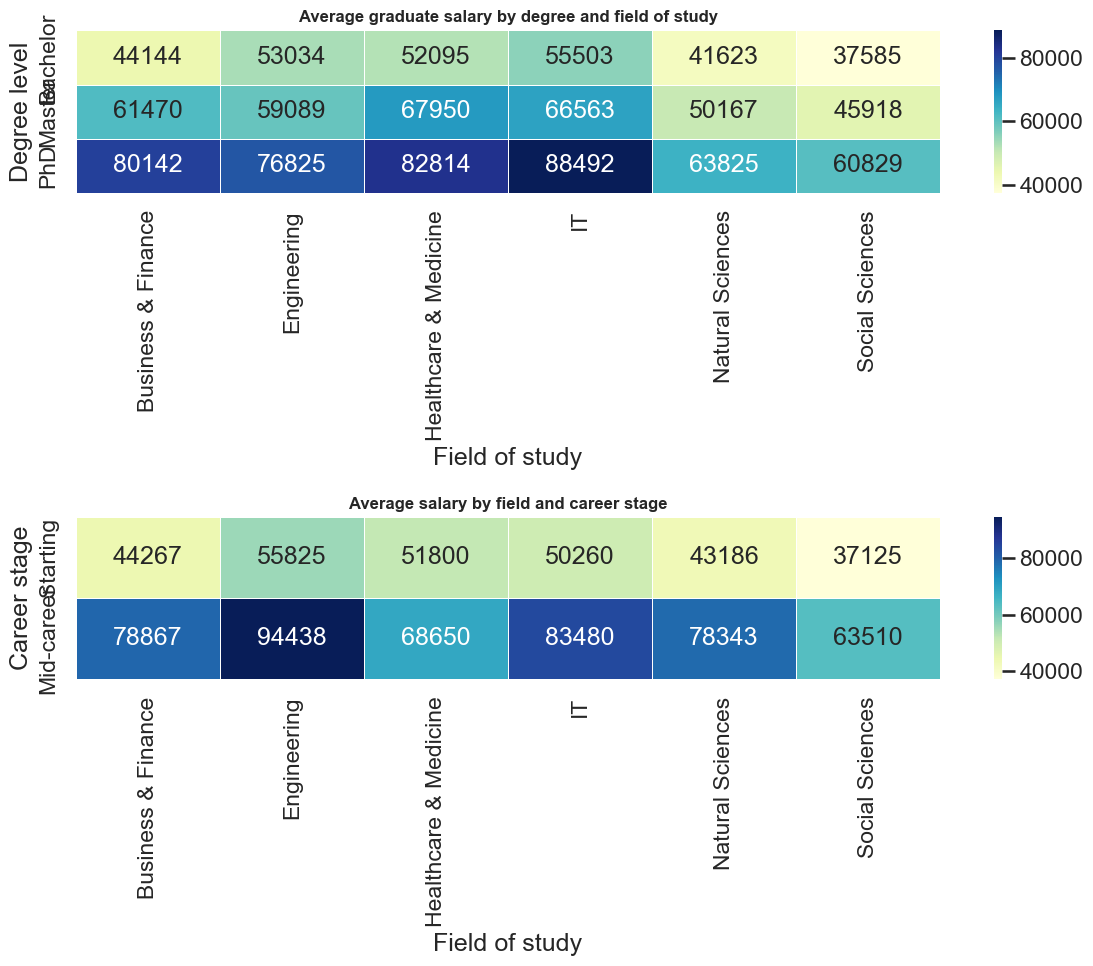

In [734]:

salary_heatmap = analysis_data.pivot_table(
    index="Degree",
    columns="Field",
    values=salary_col,
    aggfunc="mean"
)

career_heatmap = result.set_index('Field')[['avg_starting_salary', 'avg_mid_career_salary']]
career_heatmap.columns = ['Starting', 'Mid-career']

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

sns.heatmap(
    salary_heatmap,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu",
    linewidths=0.5,
    ax=ax1
)
ax1.set_title("Average graduate salary by degree and field of study", fontsize=12)
ax1.set_xlabel("Field of study")
ax1.set_ylabel("Degree level")

sns.heatmap(
    career_heatmap.T,            
    annot=True,
    fmt=".0f",
    cmap="YlGnBu",
    linewidths=0.5,
    ax=ax2
)
ax2.set_title("Average salary by field and career stage", fontsize=12)
ax2.set_xlabel("Field of study")
ax2.set_ylabel("Career stage")

plt.tight_layout()
plt.show()

In [735]:
with open('buffer.pkl', 'wb') as f:
    pickle.dump((mean_salary_uni_deg, alumni_data, analysis_data, result, salary_col), f)